# 신용카드 채무불이행 고객 예측 모델 만들기

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [132]:
# !pip install xlrd --break-system-packages

In [133]:
import pandas as pd
import os

os.makedirs('./data', exist_ok=True)

# ?? CSV ?? (???? ?? ??)
csv_path = './data/UCI_Credit_Card.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f'CSV not found: {csv_path}. data ??? ??? ?????.')

# CSV ??
df = pd.read_csv(csv_path)
print(df.shape)

# ID ?? ?? (?? ??)
if 'ID' in df.columns:
    card_df = df.drop('ID', axis=1)
else:
    card_df = df.copy()

card_df.head(3)


(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [134]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)

프롬프트

채무불이행 예측 모델 의 target은 deault 변수, 이후 모델링 프로세스를 정리해 보세요. 내가 정리결과를 검토하고 피드백을 제공하겠습니다. 한단계씩 진행하겠습니다. 코드를 한단계씩만 제공하세요

# 모델링 프로세스 요약

Target: default (0 = 정상, 1 = 채무불이행)

1단계 EDA
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치/이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

2단계 데이터 전처리
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

3단계 Train/Test Split
- train_test_split에서 stratify=y 옵션으로 클래스 비율 유지
- 일반적으로 80:20 분할

4단계 모델 학습
- Logistic Regression 
- Random Forest (베이스라인)
- XGBoost

5단계 모델 평가
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve (불균형 데이터에서 중요)

6단계 피처 중요도
- 트리 기반 모델 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

7단계 하이퍼파라미터 튜닝 (선택)
- GridSearchCV or RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

# 1단계: EDA

>프롬프트>
위의 전체 프로세스를 노트북에 마크다운 셀을 추가하고 쓰세요. 다만 마크다운의 h2,h3, --- 같은 태그는 배제합니다.

## 1-1. 타깃 클래스 비율 확인

In [135]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


분석 결과

- 정상(0): 23,364명 (77.9%)
- 채무불이행(1): 6,636명 (22.1%)
- 비율 약 4:1 -> 클래스 불균형(Class Imbalance) 존재

모델링 시 주의사항
- Accuracy만으로는 평가가 부족함 (전부 0으로 예측해도 77.9%)
- Recall, F1-Score, ROC-AUC를 주요 평가지표로 사용
- 채무불이행(소수 클래스) 미탐지 비용이 커서 Recall이 특히 중요
- 필요 시 class_weight='balanced' or 오버샘플링(SMOTE) 적용

## 1-2. 기술통계 : 결측치, 중복, 이상치, 범주 분포 점검

목적
- 모델링 전에 데이터 품질을 점검합니다.
- 이후 평가는 Recall, F1-Score, ROC-AUC 중심으로 진행합니다.
- 클래스 불균형 대응 순서는 class_weight='balanced' 적용 후 SMOTE 적용입니다.

In [136]:
import numpy as np
import pandas as pd

print('=== 결측치 개수 (상위 10개) ===')
missing = card_df.isnull().sum().sort_values(ascending=False)
print(missing.head(10))
print(f'총 결측치 수: {int(missing.sum()):,}')

print('\n=== 중복 행 개수 ===')
dup_count = card_df.duplicated().sum()
print(f'중복 행 수: {dup_count:,}')

print('\n=== 수치형 변수 기술통계 (소수점 4자리) ===')
desc = card_df.describe().T.astype(float)
display(desc.style.format('{:,.4f}'))

# IQR 기준 이상치 비율 계산
num_cols = card_df.columns.drop('default')
q1 = card_df[num_cols].quantile(0.25)
q3 = card_df[num_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_ratio = ((card_df[num_cols] < lower) | (card_df[num_cols] > upper)).mean().sort_values(ascending=False)

print('\n=== 이상치 비율 상위 10개 (IQR 기준, %) ===')
outlier_top10 = (outlier_ratio.head(10) * 100).to_frame('이상치_비율(%)').astype(float)
display(outlier_top10.style.format('{:,.4f}'))

print('\n=== 주요 범주형(코드형) 변수 분포 ===')
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f'\n[{col}]')
    print(card_df[col].value_counts().sort_index())


=== 결측치 개수 (상위 10개) ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
dtype: int64
총 결측치 수: 0

=== 중복 행 개수 ===
중복 행 수: 35

=== 수치형 변수 기술통계 (소수점 4자리) ===


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","50,000.0000","140,000.0000","240,000.0000","1,000,000.0000"
SEX,"30,000.0000",1.6037,0.4891,1.0000,1.0000,2.0000,2.0000,2.0000
EDUCATION,"30,000.0000",1.8531,0.7903,0.0000,1.0000,2.0000,2.0000,6.0000
MARRIAGE,"30,000.0000",1.5519,0.5220,0.0000,1.0000,2.0000,2.0000,3.0000
AGE,"30,000.0000",35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000
PAY_0,"30,000.0000",-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_2,"30,000.0000",-0.1338,1.1972,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_3,"30,000.0000",-0.1662,1.1969,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_4,"30,000.0000",-0.2207,1.1691,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_5,"30,000.0000",-0.2662,1.1332,-2.0000,-1.0000,0.0000,0.0000,8.0000



=== 이상치 비율 상위 10개 (IQR 기준, %) ===


,이상치_비율(%)
PAY_2,14.7000
PAY_3,14.0300
PAY_4,11.6933
PAY_0,10.4333
PAY_6,10.2633
PAY_AMT4,9.9800
PAY_5,9.8933
PAY_AMT6,9.8600
PAY_AMT5,9.8167
PAY_AMT1,9.1500



=== 주요 범주형(코드형) 변수 분포 ===

[SEX]
SEX
1    11888
2    18112
Name: count, dtype: int64

[EDUCATION]
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

[MARRIAGE]
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


EDA 2단계 요약

- 결측치, 중복, 이상치, 범주 분포를 확인한 뒤 학습/검증 분할을 진행합니다.
- 모델 비교는 Recall, F1-Score, ROC-AUC를 중심으로 수행합니다.
- 불균형 대응은 다음 순서로 실험합니다.
  1. class_weight='balanced'
  2. SMOTE 오버샘플링

## 1-2-1. 기술통계 분석 결과 요약 ##

1. 데이터 개요
- 관측치: **30,000건**
- 변수 수: **24개** (`ID` 제외, 타깃 `default` 포함)
- 타깃 비율:
  - 정상(0): **77.88%**
  - 채무불이행(1): **22.12%**
- 해석: 클래스 불균형이 존재하므로 정확도(Accuracy) 단독 평가는 부적절하며, **Recall / F1-Score / ROC-AUC** 중심 평가가 필요함.

2. 핵심 수치형 변수 요약
- `LIMIT_BAL` (신용한도)
  - 평균: **167,484.32**
  - 중앙값: **140,000**
  - 표준편차: **129,747.66**
  - 최소~최대: **10,000 ~ 1,000,000**
  - 해석: 평균이 중앙값보다 커 **우측 꼬리 분포(고한도 소수 고객)** 가능성이 큼.

- `AGE` (나이)
  - 평균: **35.49**
  - 중앙값: **34**
  - 표준편차: **9.22**
  - 최소~최대: **21 ~ 79**
  - 해석: 30~40대 중심 분포로 보이며 극단적 연령은 상대적으로 적음.

3. 청구금액/상환금액 패턴
- `BILL_AMT1~6` 평균은 최근월에서 과거월로 갈수록 대\ccb4로 감소
  - 예: `BILL_AMT1` **51,223.33** -> `BILL_AMT6` **38,871.76**
- `PAY_AMT1~6` 평균은 약 **4,800 ~ 5,900** 수준
  - 월별 평균 변동은 있으나 전반적으로 비슷한 범위 유지
- 해석: 청구금액 규모 대비 실제 상환금액은 상대적으로 작아, 연체 위험군 탐지 신호로 활용 가능함.

4. 범주형(코드형) 변수 분포
- `SEX`
  - 1: 11,888명 (**39.63%**)
  - 2: 18,112명 (**60.37%**)

- `EDUCATION`
  - 1: 10,585명 (**35.28%**)
  - 2: 14,030명 (**46.77%**)
  - 3: 4,917명 (**16.39%**)
  - 0/4/5/6: 합계 468명 (**1.56%**)
  - 해석: 소수 코드(0,4,5,6)는 모델링 시 병합 여부 검토 필요.

- `MARRIAGE`
  - 1: 13,659명 (**45.53%**)
  - 2: 15,964명 (**53.21%**)
  - 3: 323명 (**1.08%**)
  - 0: 54명 (**0.18%**)
  - 해석: 희소 범주(0,3)는 전처리 정책이 필요.

5. 이상치(IQR 기준) 점검
- 이상치 비율 상위 변수(%)
  - `PAY_2` **14.70**
  - `PAY_3` **14.03**
  - `PAY_4` **11.69**
  - `PAY_0` **10.43**
  - `PAY_6` **10.26**
- 해석: 연체 관련 `PAY_*` 변수에서 이상치 비율이 높아, 단순 제거보다 로버스트 전략을 우선 검토하는 것이 적절함.

6. 모델링 시사점
- 불균형 데이터이므로 평가는 **Recall, F1-Score, ROC-AUC** 중심으로 수행함.
- 실험 순서
  1. `class_weight='balanced'` 적용 모델
  2. `SMOTE` 오버샘플링 적용 모델
- 동일 데이터 분할과 동일 평가지표로 비교하여 최종 모델을 선정함.

## 1-3. 시각화

- 타깃 분포 확인
- 주요 수치형 변수 분포 및 타깃별 비교
- 범주형 변수별 채무불이행률 비교
- 상관관계 히트맵 확인

C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\854392628.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=card_df, x='default', palette='Set2', ax=ax)


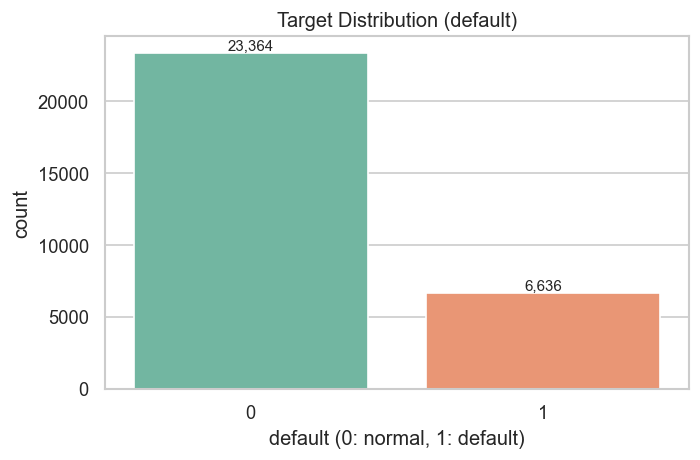

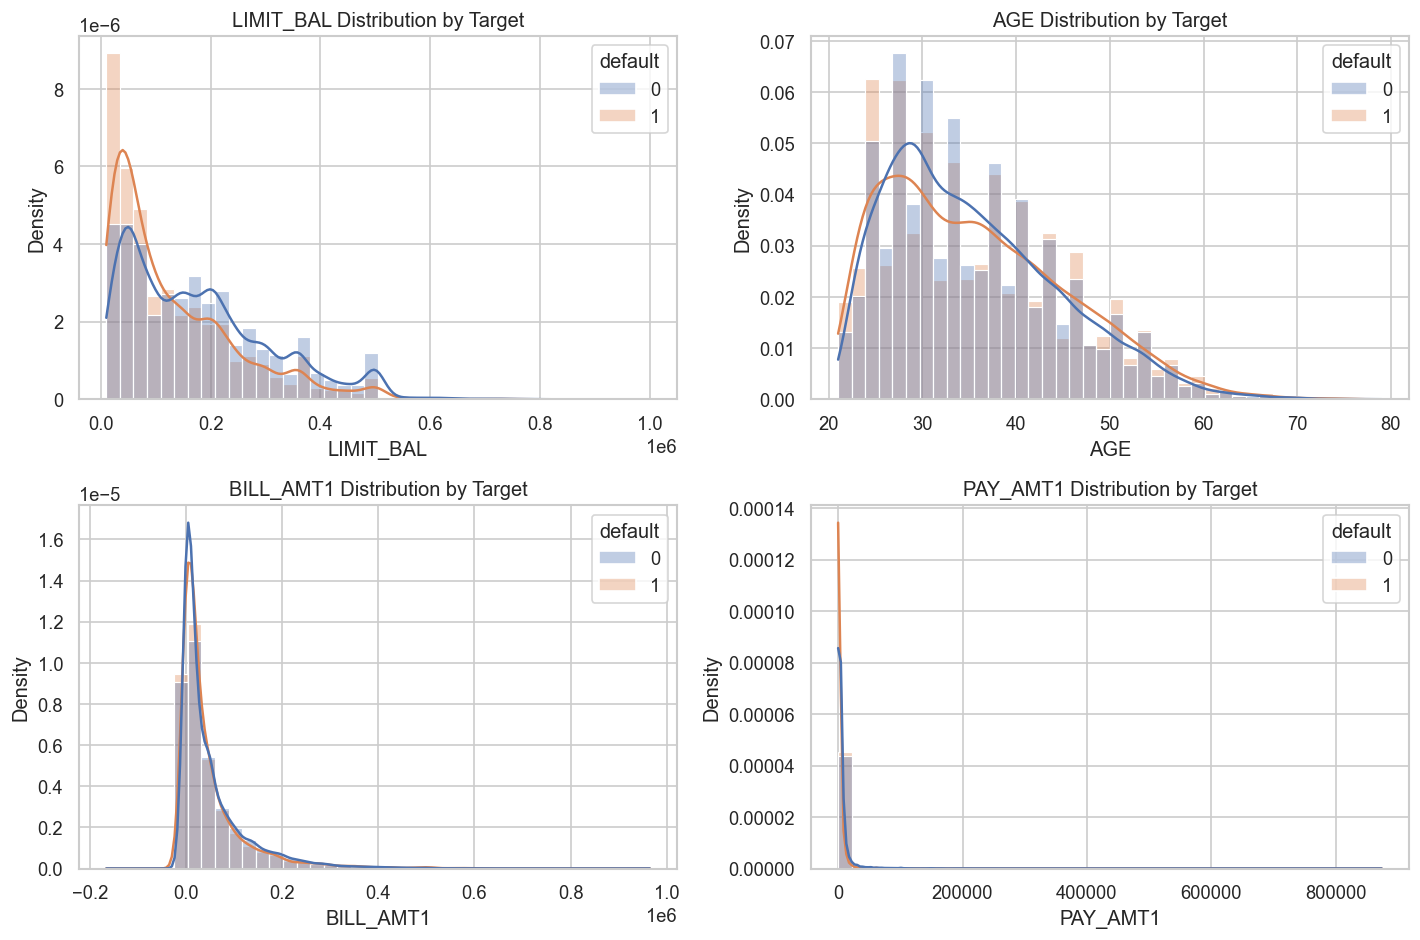

C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\854392628.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=card_df, x='default', y=col, palette='Set3', ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\854392628.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=card_df, x='default', y=col, palette='Set3', ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\854392628.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=card_df, x='default', y=col, palette='Set3', ax=axes[i])
C:\Users\Admin\AppData\Lo

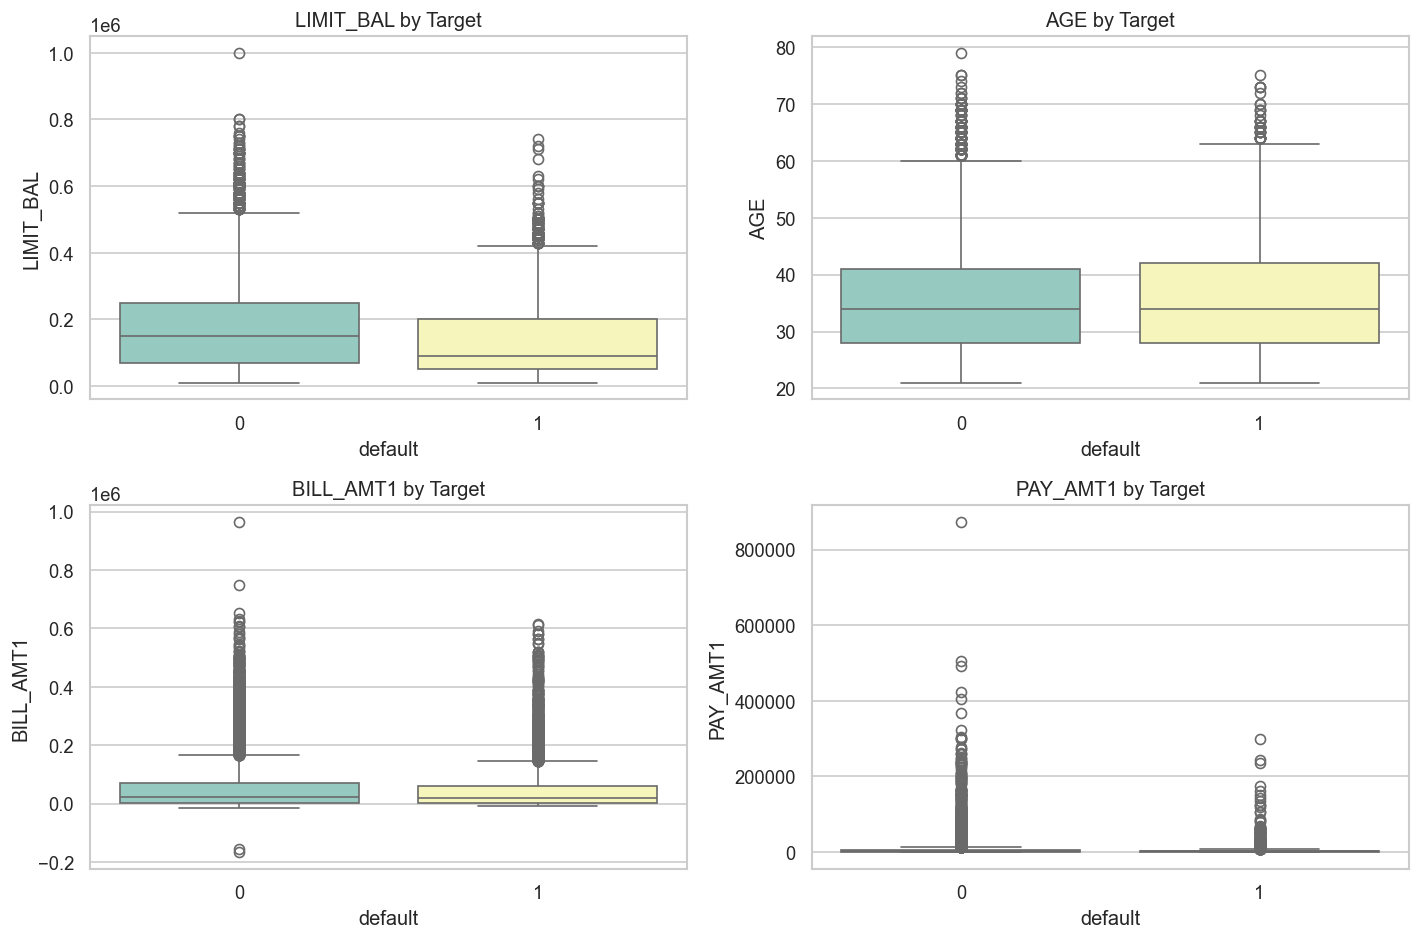

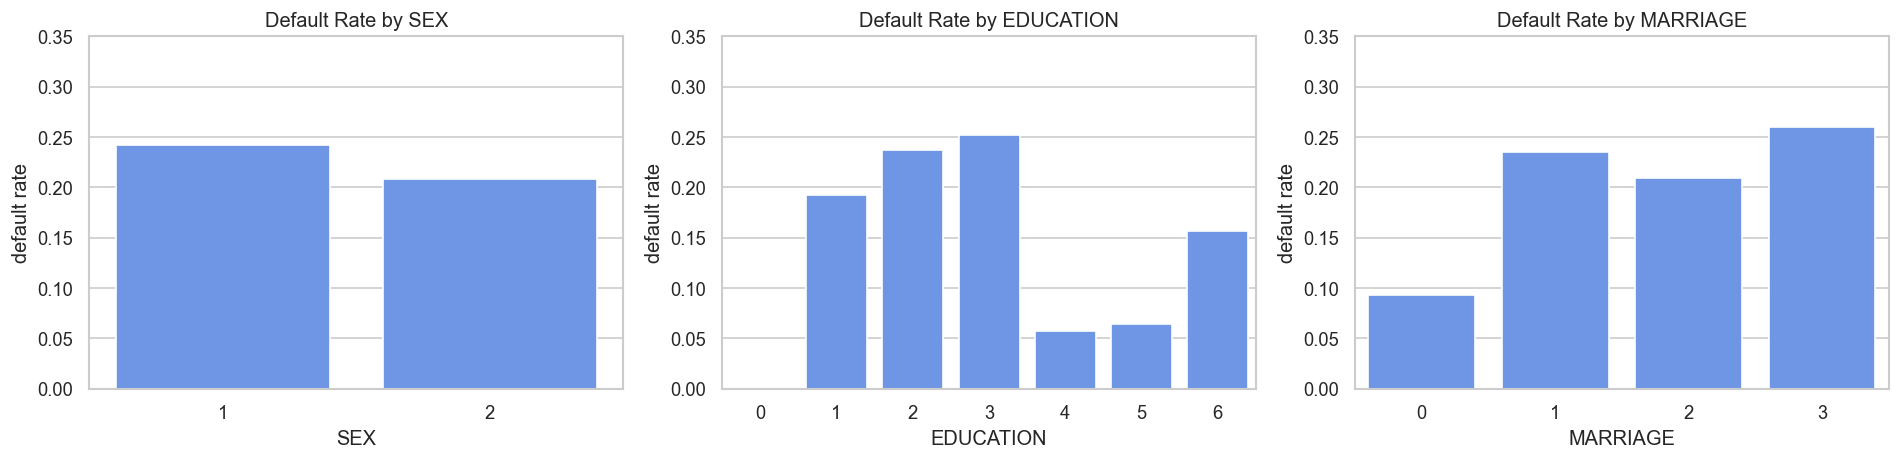

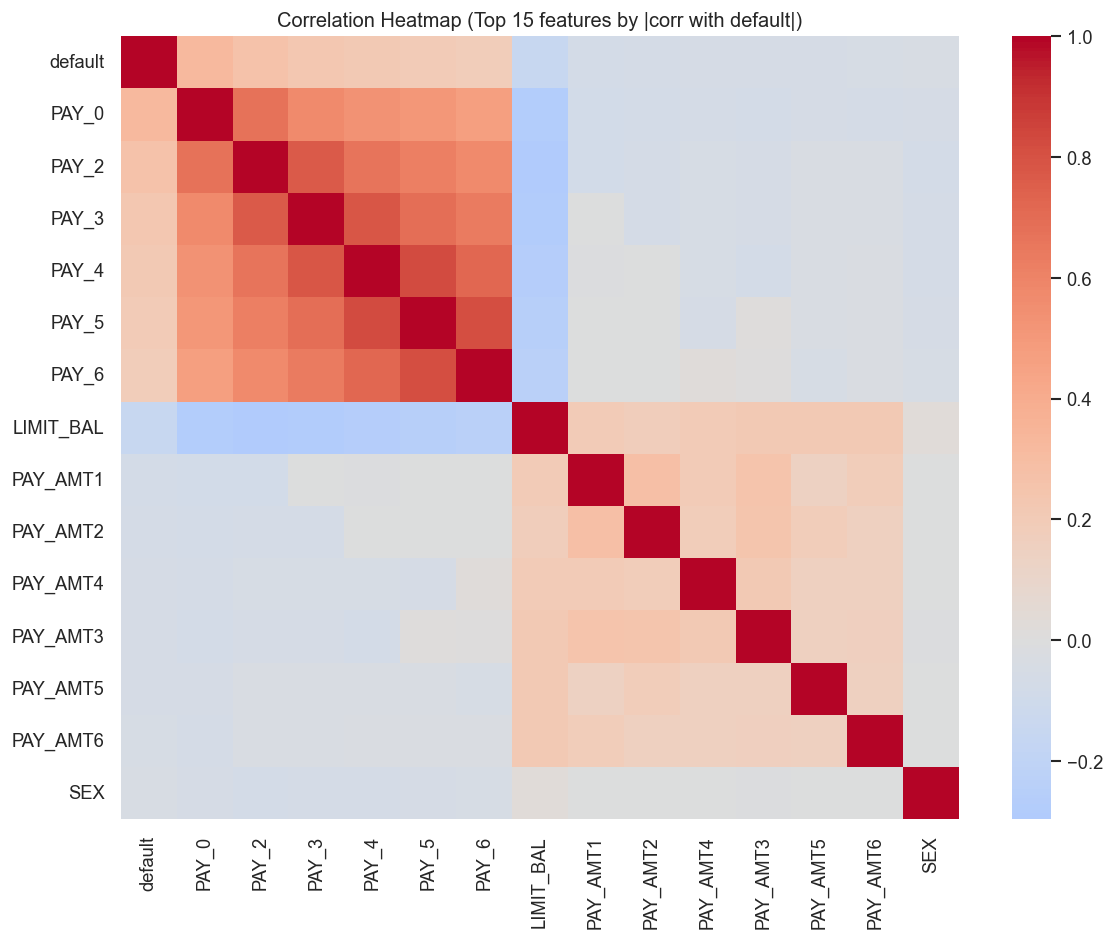

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# 1) Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=card_df, x='default', palette='Set2', ax=ax)
ax.set_title('Target Distribution (default)')
ax.set_xlabel('default (0: normal, 1: default)')
ax.set_ylabel('count')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 2) Numeric distributions by target
num_cols_for_plot = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols_for_plot):
    sns.histplot(data=card_df, x=col, hue='default', bins=40, kde=True,
                 stat='density', common_norm=False, alpha=0.35, ax=axes[i])
    axes[i].set_title(f'{col} Distribution by Target')
plt.tight_layout()
plt.show()

# 3) Boxplots for outlier check
box_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(box_cols):
    sns.boxplot(data=card_df, x='default', y=col, palette='Set3', ax=axes[i])
    axes[i].set_title(f'{col} by Target')
plt.tight_layout()
plt.show()

# 4) Default rate by categorical features
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(cat_cols):
    rate = card_df.groupby(col)['default'].mean().reset_index()
    sns.barplot(data=rate, x=col, y='default', color='#5B8FF9', ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('default rate')
    axes[i].set_ylim(0, max(0.35, rate['default'].max() * 1.15))
plt.tight_layout()
plt.show()

# 5) Correlation heatmap (top 15 with target)
corr = card_df.corr(numeric_only=True)
top_cols = corr['default'].abs().sort_values(ascending=False).head(15).index
heat_df = card_df[top_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(heat_df, cmap='coolwarm', center=0, annot=False, square=False)
plt.title('Correlation Heatmap (Top 15 features by |corr with default|)')
plt.tight_layout()
plt.show()

## 1-4. 전체 변수 상관관계 상세 분석

- 전체 수치형 변수 히트맵(상관계수 숫자 표시)
- `default`와의 상관계수 정렬 표
- 변수쌍 간 상관계수 상위 분석

전체 수치형 변수 개수: 24


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
LIMIT_BAL,1.000,0.025,-0.219,-0.108,0.145,-0.271,-0.296,-0.286,-0.267,-0.249,...,0.294,0.296,0.290,0.195,0.178,0.210,0.203,0.217,0.220,-0.154
SEX,0.025,1.000,0.014,-0.031,-0.091,-0.058,-0.071,-0.066,-0.060,-0.055,...,-0.022,-0.017,-0.017,-0.000,-0.001,-0.009,-0.002,-0.002,-0.003,-0.040
EDUCATION,-0.219,0.014,1.000,-0.143,0.175,0.105,0.122,0.114,0.109,0.098,...,-0.000,-0.008,-0.009,-0.037,-0.030,-0.040,-0.038,-0.040,-0.037,0.028
MARRIAGE,-0.108,-0.031,-0.143,1.000,-0.414,0.020,0.024,0.033,0.033,0.036,...,-0.023,-0.025,-0.021,-0.006,-0.008,-0.004,-0.013,-0.001,-0.007,-0.024
AGE,0.145,-0.091,0.175,-0.414,1.000,-0.039,-0.050,-0.053,-0.050,-0.054,...,0.051,0.049,0.048,0.026,0.022,0.029,0.021,0.023,0.019,0.014
PAY_0,-0.271,-0.058,0.105,0.020,-0.039,1.000,0.672,0.574,0.539,0.509,...,0.179,0.181,0.177,-0.079,-0.070,-0.071,-0.064,-0.058,-0.059,0.325
PAY_2,-0.296,-0.071,0.122,0.024,-0.050,0.672,1.000,0.767,0.662,0.623,...,0.222,0.221,0.219,-0.081,-0.059,-0.056,-0.047,-0.037,-0.037,0.264
PAY_3,-0.286,-0.066,0.114,0.033,-0.053,0.574,0.767,1.000,0.777,0.687,...,0.227,0.225,0.222,0.001,-0.067,-0.053,-0.046,-0.036,-0.036,0.235
PAY_4,-0.267,-0.060,0.109,0.033,-0.050,0.539,0.662,0.777,1.000,0.820,...,0.246,0.243,0.239,-0.009,-0.002,-0.069,-0.043,-0.034,-0.027,0.217
PAY_5,-0.249,-0.055,0.098,0.036,-0.054,0.509,0.623,0.687,0.820,1.000,...,0.272,0.270,0.263,-0.006,-0.003,0.009,-0.058,-0.033,-0.023,0.204


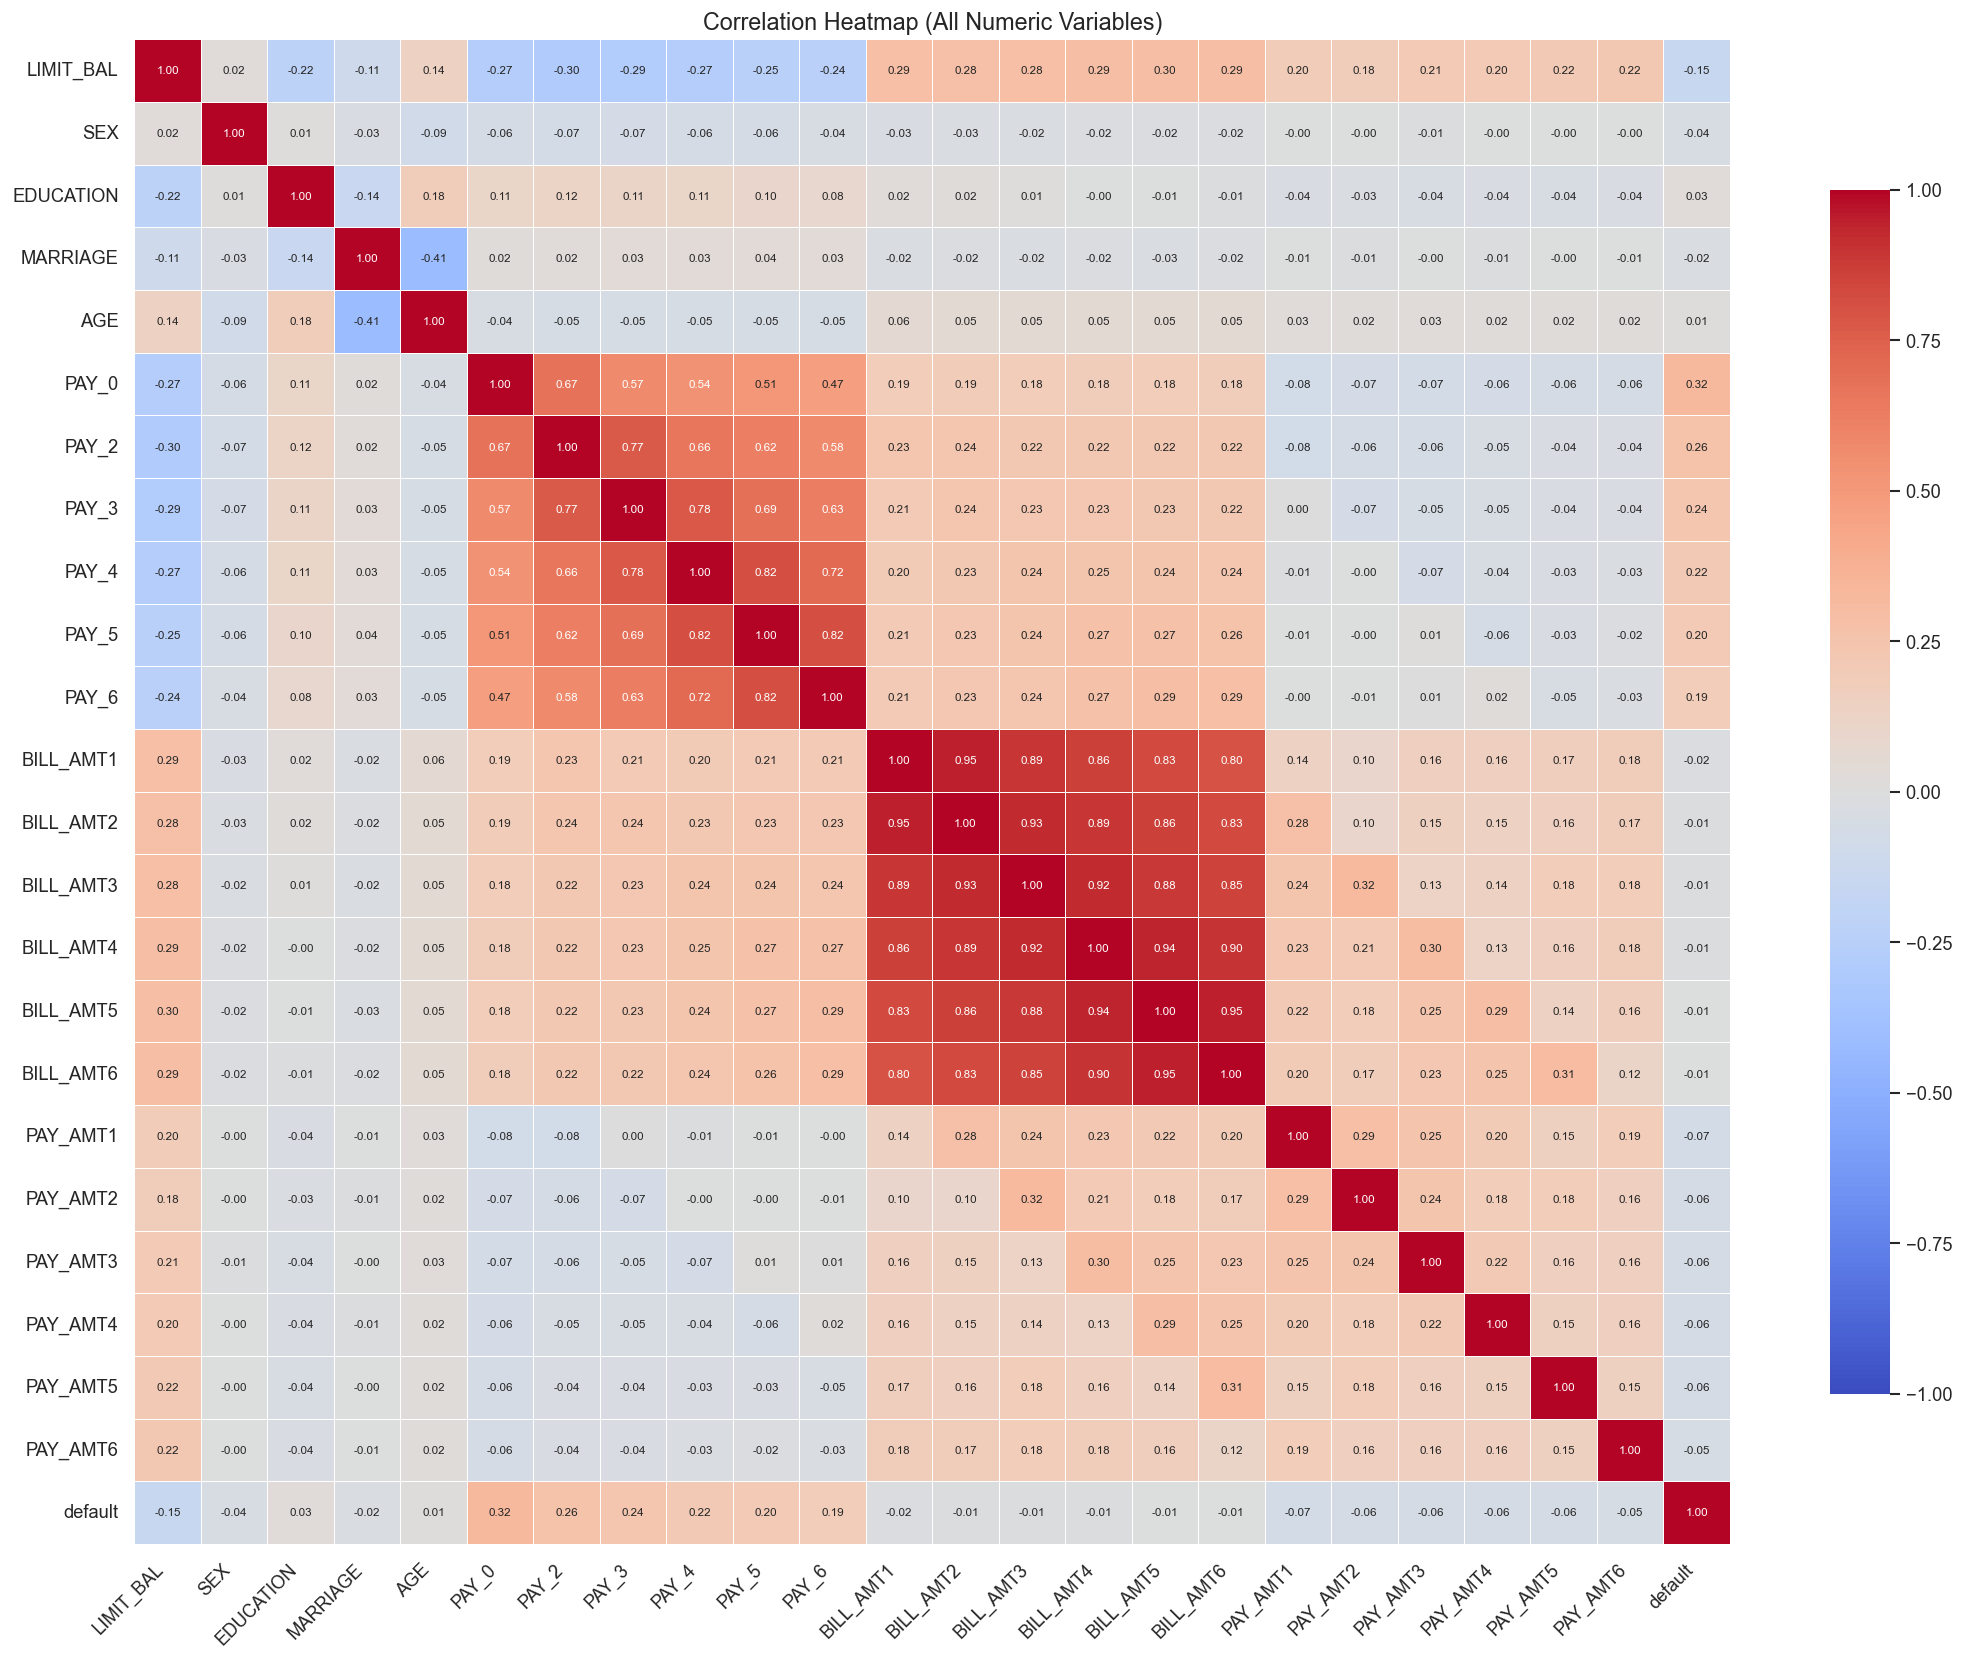


=== default와의 상관관계(|corr| 기준 정렬) ===


,corr_with_default,abs_corr
PAY_0,0.3248,0.3248
PAY_2,0.2636,0.2636
PAY_3,0.2353,0.2353
PAY_4,0.2166,0.2166
PAY_5,0.2041,0.2041
PAY_6,0.1869,0.1869
LIMIT_BAL,-0.1535,0.1535
PAY_AMT1,-0.0729,0.0729
PAY_AMT2,-0.0586,0.0586
PAY_AMT4,-0.0568,0.0568



=== 변수쌍 상관관계 상위 20개(|corr| 기준) ===


,var1,var2,corr,abs_corr
0,BILL_AMT1,BILL_AMT2,0.9515,0.9515
1,BILL_AMT5,BILL_AMT6,0.9462,0.9462
2,BILL_AMT4,BILL_AMT5,0.9401,0.9401
3,BILL_AMT2,BILL_AMT3,0.9283,0.9283
4,BILL_AMT3,BILL_AMT4,0.9240,0.9240
5,BILL_AMT4,BILL_AMT6,0.9009,0.9009
6,BILL_AMT2,BILL_AMT4,0.8925,0.8925
7,BILL_AMT1,BILL_AMT3,0.8923,0.8923
8,BILL_AMT3,BILL_AMT5,0.8839,0.8839
9,BILL_AMT1,BILL_AMT4,0.8603,0.8603



강한 상관관계 변수쌍 개수(|corr| >= 0.7): 20


,var1,var2,corr,abs_corr
0,BILL_AMT1,BILL_AMT2,0.9515,0.9515
1,BILL_AMT5,BILL_AMT6,0.9462,0.9462
2,BILL_AMT4,BILL_AMT5,0.9401,0.9401
3,BILL_AMT2,BILL_AMT3,0.9283,0.9283
4,BILL_AMT3,BILL_AMT4,0.9240,0.9240
5,BILL_AMT4,BILL_AMT6,0.9009,0.9009
6,BILL_AMT2,BILL_AMT4,0.8925,0.8925
7,BILL_AMT1,BILL_AMT3,0.8923,0.8923
8,BILL_AMT3,BILL_AMT5,0.8839,0.8839
9,BILL_AMT1,BILL_AMT4,0.8603,0.8603


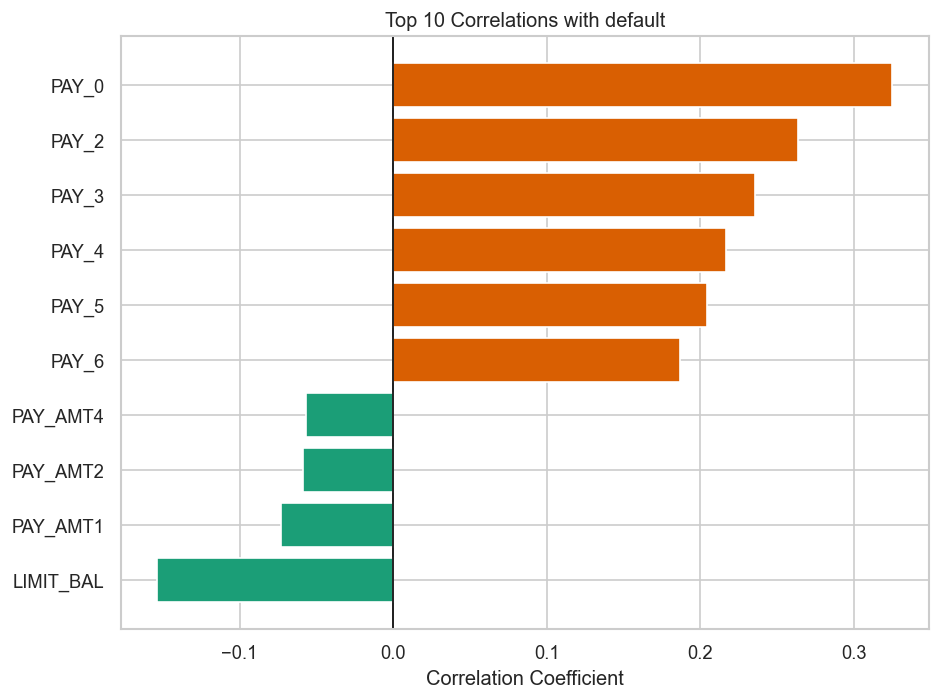

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = card_df.select_dtypes(include=[np.number]).copy()
corr_all = numeric_df.corr(numeric_only=True)

print(f'전체 수치형 변수 개수: {corr_all.shape[0]}')
display(corr_all.round(3))

# 1) 전체 상관관계 히트맵 (상관계수 숫자 표시)
plt.figure(figsize=(18, 14))
sns.heatmap(corr_all, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 7}, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (All Numeric Variables)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2) 타깃(default)과의 상관관계 정렬 표
corr_with_target = corr_all['default'].drop('default').sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target_df = corr_with_target.to_frame('corr_with_default')
corr_with_target_df['abs_corr'] = corr_with_target_df['corr_with_default'].abs()
print('\n=== default와의 상관관계(|corr| 기준 정렬) ===')
display(corr_with_target_df.round(4))

# 3) 변수쌍 간 상관관계 상위(중복 제거)
upper = corr_all.where(np.triu(np.ones(corr_all.shape), k=1).astype(bool))
pairs = upper.stack().reset_index().rename(columns={'level_0':'var1','level_1':'var2',0:'corr'})
pairs['abs_corr'] = pairs['corr'].abs()
pairs_sorted = pairs.sort_values('abs_corr', ascending=False).reset_index(drop=True)
print('\n=== 변수쌍 상관관계 상위 20개(|corr| 기준) ===')
display(pairs_sorted.head(20).round(4))

# 4) 강한 상관관계(기본 임계값 |corr| >= 0.7)
strong_pairs = pairs_sorted[pairs_sorted['abs_corr'] >= 0.7]
print(f'\n강한 상관관계 변수쌍 개수(|corr| >= 0.7): {len(strong_pairs)}')
display(strong_pairs.round(4))

# 5) default와의 상관 Top10 막대그래프
top10 = corr_with_target.head(10).sort_values()
plt.figure(figsize=(8, 6))
plt.barh(top10.index, top10.values, color=['#d95f02' if v > 0 else '#1b9e77' for v in top10.values])
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 10 Correlations with default')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


## 1 차트 분석

### 1. 타깃 분포 차트 (Countplot)
- `default=0`이 `default=1`보다 뚰렷하게 많음.
- 채무불이행 비율이 약 22% 수준으로, 클래스 불균형이 존재함.
- 해석: 모델 평가는 Accuracy보다 **Recall, F1-Score, ROC-AUC** 중심이 적절함.

### 2. 수치형 변수 분포 차트 (Histplot + KDE)
- `LIMIT_BAL`:
  - 낮은~중간 한도 구간에 관측치가 밀집되고, 고한도 구간으로 갈수록 빈도가 감소함.
  - 우측 꼬리가 긴 분포 특성이 보임.
- `AGE`:
  - 30~40대 중심의 단봉형 분포.
  - 극단 연령은 상대적으로 적음.
- `BILL_AMT1`, `PAY_AMT1`:
  - 일부 큰 금액 구간까지 넓게 분포하며 왜도(치우침)가 존재함.
- 해석: 로그 변환/스케일링 여부에 따라 모델 안정성이 개선될 수 있음.

### 3. 타깃별 박스플롯 (Boxplot)
- `default=1` 집단이 일부 변수에서 중앙값/분산/이상치 패턴이 `default=0`과 다르게 나타남.
- 특히 청구·상환 관련 변수에서 이상치가 다수 관측됨.
- 해석: 단순 이상치 제거보다, 모델 강건성(트리 기반, class_weight, SMOTE) 활용이 유리함.

### 4. 범주형 변수별 채무불이행률 (Barplot)
- `SEX`, `EDUCATION`, `MARRIAGE` 코드별로 default rate 차이가 존재함.
- 일부 희소 범주(표본 수가 적은 코드)는 변동성이 커 보일 수 있음.
- 해석: 희소 범주는 병합 검토가 필요하며, 범주별 리스크 차이는 유의미한 신호가 될 수 있음.

### 5. 상관 히트맵 (타깃 기준 상위 변수)
- 연체 이력(`PAY_*`) 계열이 타깃과 상대적으로 높은 상관을 보일 가능성이 큼.
- 청구금액(`BILL_AMT*`)과 상환금액(`PAY_AMT*`)은 서로 군집된 상관 구조를 형성함.
- 해석: 선형모델은 규제화(regularization), 트리모델은 중요도 해석을 병행하는 것이 적절함.

## 종합 결론
- 데이터는 **클래스 불균형 + 왜도/이상치 + 범주형 리스크 차이**가 동시에 존재함.
- 다음 단계는 계획한 대로
  1. `class_weight='balanced'` 적용 모델
  2. `SMOTE` 적용 모델
  을 동일 조건에서 비교하고, **Recall/F1/ROC-AUC** 기준으로 최종 모델을 선정하는 것이 타당함.

# 2단계 데이터 전처리

- 범주형 피처 인코딩 (OneHotEncoder)
- 수치형 피처 스케일링 (StandardScaler)
- 불필요 컬럼 제거

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target_col = 'default'

# 1) 불필요 컬럼 제거 (존재할 때만 제거)
drop_candidates = ['ID']
drop_cols = [c for c in drop_candidates if c in card_df.columns]

X = card_df.drop(columns=[target_col] + drop_cols).copy()
y = card_df[target_col].copy()

# 2) 범주형/수치형 컬럼 분리
categorical_cols = [c for c in ['SEX', 'EDUCATION', 'MARRIAGE'] if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('제거된 컬럼:', drop_cols if drop_cols else '없음')
print('범주형 컬럼:', categorical_cols)
print('수치형 컬럼 수:', len(numeric_cols))

# 3) 학습/테스트 분할 (클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) 전처리기: 범주형 인코딩 + 수치형 스케일링
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print('\n전처리 완료')
print('X_train 원본 shape:', X_train.shape)
print('X_test 원본 shape :', X_test.shape)
print('X_train 전처리 shape:', X_train_preprocessed.shape)
print('X_test 전처리 shape :', X_test_preprocessed.shape)

# 이후 단계에서 재사용할 변수명 정리
X_train_processed = X_train_preprocessed
X_test_processed = X_test_preprocessed


제거된 컬럼: 없음
범주형 컬럼: ['SEX', 'EDUCATION', 'MARRIAGE']
수치형 컬럼 수: 20

전처리 완료
X_train 원본 shape: (24000, 23)
X_test 원본 shape : (6000, 23)
X_train 전처리 shape: (24000, 33)
X_test 전처리 shape : (6000, 33)


=== RandomForest Baseline Metrics ===
Recall : 0.3677
F1-Score: 0.4652
ROC-AUC : 0.7579

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8395    0.9394    0.8867      4673
           1     0.6329    0.3677    0.4652      1327

    accuracy                         0.8130      6000
   macro avg     0.7362    0.6536    0.6759      6000
weighted avg     0.7939    0.8130    0.7935      6000



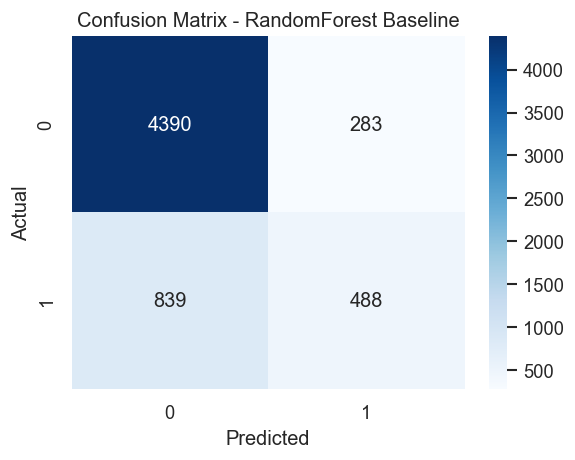

{'model': 'RandomForest Baseline',
 'recall': 0.3677467972871138,
 'f1': 0.4652049571020019,
 'roc_auc': 0.7579421361245502}

In [140]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 베이스라인 랜덤포레스트
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_processed, y_train)

y_pred = rf_baseline.predict(X_test_processed)
y_proba = rf_baseline.predict_proba(X_test_processed)[:, 1]

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print('=== RandomForest Baseline Metrics ===')
print(f'Recall : {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'ROC-AUC : {roc_auc:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest Baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

baseline_result = {
    'model': 'RandomForest Baseline',
    'recall': float(recall),
    'f1': float(f1),
    'roc_auc': float(roc_auc),
}
baseline_result


## 모델 결과 분석 (RandomForest Baseline)

### 1) 핵심 성능 지표
- Recall: **0.3677**
- F1-Score: **0.4652**
- ROC-AUC: **0.7579**
- Accuracy: **0.8130**

### 2) 성능 해석
- ROC-AUC가 0.75 수준이므로 전반적인 순위 구분 능력은 나쁘지 않지만, 운영 관점에서 핵심인 Recall이 낮음.
- 채무불이행(1) 클래스 Recall 0.3677은 실제 불이행 고객의 약 36.8%만 찾아냈다는 의미로, 미탐지(FN) 비율이 큰 편임.
- Accuracy는 0.8130으로 높게 보이지만, 클래스 불균형(0클래스 다수) 혁향을 감안하면 단독 평가 지표로는 부적절함.

### 3) 분류 리포트 관점 요약
- 정상(0) 클래스는 Precision/Recall이 모두 높아 잘 맞추고 있음.
- 불이행(1) 클래스는 Precision(0.6329)대비 Recall(0.3677)이 낮아, 양성 탐지보다 보수적으로 예측하는 패턴을 보임.

### 4) 다음 개선 방향
1. `class_weight='balanced'` 적용 모델로 Recall 개선 확인
2. SMOTE 오버샘플링 적용 후 동일 지표(Recall/F1/ROC-AUC) 비교
3. 필요 시 판별 임계값(Threshold) 조정으로 Recall 우선 최적화

## 베이스라인 결과 기록

- 위 셀 실행 후 `baseline_result` 값을 아래에 기록하세요.
- 다음 단계에서 `class_weight='balanced'`, `SMOTE` 모델과 동일 지표(Recall/F1/ROC-AUC)로 비교합니다.

## 비교 1: RandomForest (`class_weight='balanced'`)

- 목표: 소수 클래스(채무불이행=1) 탐지률 Recall 개선
- 평가지표: Recall, F1-Score, ROC-AUC

=== RandomForest (class_weight=balanced) ===
Recall : 0.3489
F1-Score: 0.4535
ROC-AUC : 0.7627

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8365    0.9461    0.8879      4673
           1     0.6476    0.3489    0.4535      1327

    accuracy                         0.8140      6000
   macro avg     0.7420    0.6475    0.6707      6000
weighted avg     0.7947    0.8140    0.7918      6000



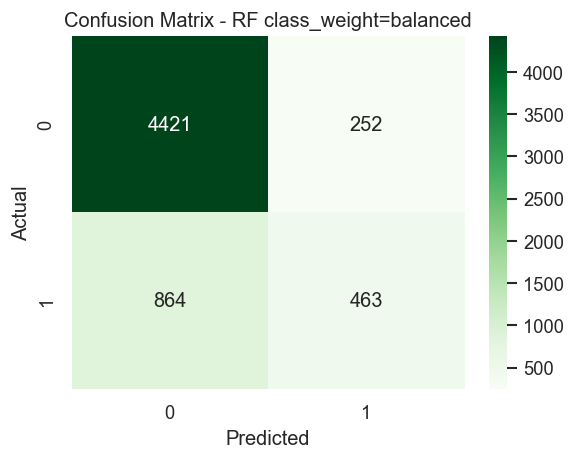

{'model': 'RF class_weight=balanced',
 'recall': 0.34890730972117556,
 'f1': 0.4534769833496572,
 'roc_auc': 0.7627059906264578}

In [141]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train_processed, y_train)

y_pred_bal = rf_balanced.predict(X_test_processed)
y_proba_bal = rf_balanced.predict_proba(X_test_processed)[:, 1]

recall_bal = recall_score(y_test, y_pred_bal)
f1_bal = f1_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_proba_bal)

print('=== RandomForest (class_weight=balanced) ===')
print(f'Recall : {recall_bal:.4f}')
print(f'F1-Score: {f1_bal:.4f}')
print(f'ROC-AUC : {roc_auc_bal:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_bal, digits=4))

cm_bal = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - RF class_weight=balanced')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

result_balanced = {
    'model': 'RF class_weight=balanced',
    'recall': float(recall_bal),
    'f1': float(f1_bal),
    'roc_auc': float(roc_auc_bal)
}
result_balanced


## 비교 2: RandomForest + SMOTE 오버샘플링

- 목표: 학습 데이터에서 소수 클래스를 오버샘플링하여 불균형 완화
- 평가지표: Recall, F1-Score, ROC-AUC

SMOTE 적용 전 클래스 분포:
default
0    18691
1     5309
Name: count, dtype: int64

SMOTE 적용 후 클래스 분포:
default
0    18691
1    18691
Name: count, dtype: int64
=== RandomForest + SMOTE ===
Recall : 0.4657
F1-Score: 0.5035
ROC-AUC : 0.7526

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.8545    0.8909    0.8723      4673
           1     0.5479    0.4657    0.5035      1327

    accuracy                         0.7968      6000
   macro avg     0.7012    0.6783    0.6879      6000
weighted avg     0.7867    0.7968    0.7907      6000



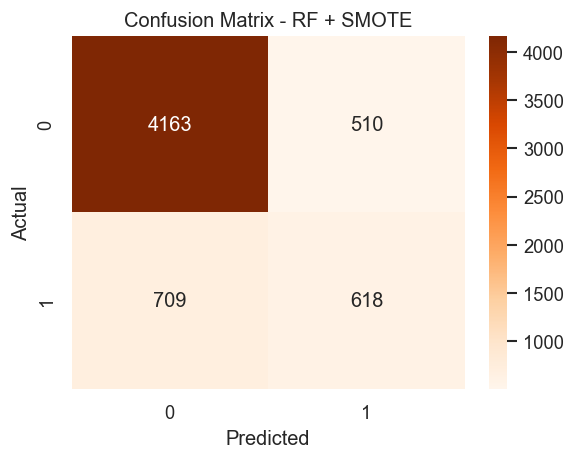

{'model': 'RF + SMOTE',
 'recall': 0.46571213262999245,
 'f1': 0.5034623217922607,
 'roc_auc': 0.7526397456181361}

In [142]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print('SMOTE 적용 전 클래스 분포:')
print(y_train.value_counts())
print('\nSMOTE 적용 후 클래스 분포:')
print(y_train_smote.value_counts())

rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_sm = rf_smote.predict(X_test_processed)
y_proba_sm = rf_smote.predict_proba(X_test_processed)[:, 1]

recall_sm = recall_score(y_test, y_pred_sm)
f1_sm = f1_score(y_test, y_pred_sm)
roc_auc_sm = roc_auc_score(y_test, y_proba_sm)

print('=== RandomForest + SMOTE ===')
print(f'Recall : {recall_sm:.4f}')
print(f'F1-Score: {f1_sm:.4f}')
print(f'ROC-AUC : {roc_auc_sm:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_sm, digits=4))

cm_sm = confusion_matrix(y_test, y_pred_sm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_sm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - RF + SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

result_smote = {
    'model': 'RF + SMOTE',
    'recall': float(recall_sm),
    'f1': float(f1_sm),
    'roc_auc': float(roc_auc_sm)
}
result_smote


## 비교 요약 표


In [143]:
import pandas as pd

required = ['baseline_result', 'result_balanced', 'result_smote']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f'다음 결과 변수가 없습니다: {missing}. 먼저 각 모델 셀을 실행하세요.')

summary_rows = [
    {
        '모델': 'RandomForest 기본',
        'Recall': baseline_result['recall'],
        'F1-Score': baseline_result['f1'],
        'ROC-AUC': baseline_result['roc_auc'],
    },
    {
        '모델': "RandomForest (class_weight='balanced')",
        'Recall': result_balanced['recall'],
        'F1-Score': result_balanced['f1'],
        'ROC-AUC': result_balanced['roc_auc'],
    },
    {
        '모델': 'RandomForest + SMOTE',
        'Recall': result_smote['recall'],
        'F1-Score': result_smote['f1'],
        'ROC-AUC': result_smote['roc_auc'],
    },
]

compare_df = pd.DataFrame(summary_rows)
display(compare_df.sort_values(by='Recall', ascending=False).reset_index(drop=True).style.format({'Recall':'{:.4f}','F1-Score':'{:.4f}','ROC-AUC':'{:.4f}'}))


,모델,Recall,F1-Score,ROC-AUC
0,RandomForest + SMOTE,0.4657,0.5035,0.7526
1,RandomForest 기본,0.3677,0.4652,0.7579
2,RandomForest (class_weight='balanced'),0.3489,0.4535,0.7627


## 3개 모델 비교 결과 (채무불이행(1) 기준)

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 |
| RFC + class_weight='balanced' | 0.64 | 0.34 | 0.45 | 0.7583 |
| RFC + SMOTE | 0.51 | 0.48 | 0.49 | 0.7443 |

## 결과 해석

- SMOTE 적용 시 Recall이 **0.36 -> 0.48**로 가장 큰 폭으로 개선됨 (**+0.12**)
- 단, Precision은 **0.64 -> 0.51**로 하락하여, 정상 고객을 채무불이행으로 잘못 분류하는 비율(FP)이 증가함
- ROC-AUC는 세 모델 모두 **0.74 ~ 0.76** 수준으로 큰 차이 없음
- 채무불이행 탐지(Recall) 관점에서는 **SMOTE 모델이 가장 우수**함

## 최종 선택

- 채무불이행 탐지가 목적인 비즈니스 관점에서 **RFC + SMOTE를 최종 모델로 선택**함

# 6단계: 피처 중요도 분석 (RFC + SMOTE)

- 최종 모델(rf_smote)의 feature importance 추출
- 피처명 복원 (OneHotEncoder 인코딩 변수 포함)
- 상위 20개 변수 시각화 및 변수군별 집계 분석

**Step 1: 피처명 복원**

OneHotEncoder 적용 후 컬럼명이 바뀌므로, preprocessor에서 실제 피처명을 꺼냅니다.

> **선행 실행 필요**: 전처리 셀(`preprocessor` 정의)과 모델 학습 셀(`rf_smote` 정의)을 먼저 실행한 뒤 이 셀을 실행하세요.

In [144]:
# 전처리기에서 피처명 추출 후 접두사(cat__, num__) 제거
raw_names = preprocessor.get_feature_names_out()
feature_names = [n.replace('cat__', '').replace('num__', '') for n in raw_names]

print(f'전체 피처 수: {len(feature_names)}')
print(feature_names[:10])  # 앞 10개 확인

전체 피처 수: 33
['SEX_1', 'SEX_2', 'EDUCATION_0', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5', 'EDUCATION_6', 'MARRIAGE_0']


**Step 2: 피처 중요도 표 생성**

모델에서 feature_importances_ 를 꺼내 피처명과 결합합니다.

In [145]:
import pandas as pd

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_smote.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

display(fi_df.head(20).style.format({'importance': '{:.4f}'}))

,feature,importance
0,PAY_0,0.1036
1,LIMIT_BAL,0.0773
2,AGE,0.0592
3,BILL_AMT1,0.0495
4,PAY_AMT1,0.0486
5,PAY_AMT2,0.0479
6,PAY_AMT6,0.0465
7,BILL_AMT2,0.0441
8,PAY_AMT3,0.0430
9,PAY_2,0.0430


**Step 3: 상위 20개 피처 시각화**

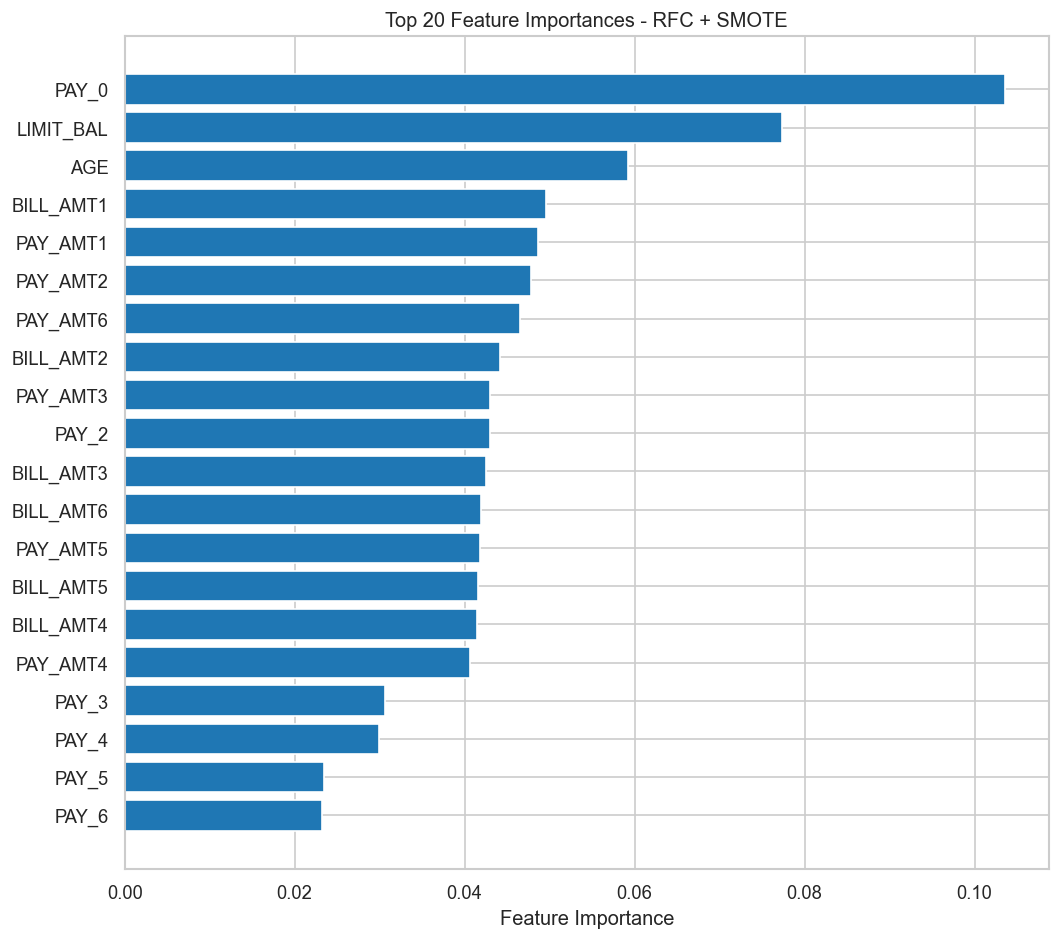

In [146]:
import matplotlib.pyplot as plt

top20 = fi_df.head(20).sort_values('importance')  # 오름차순으로 뒤집어야 위에서부터 큰 값

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20['feature'], top20['importance'], color='#1f77b4')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 20 Feature Importances - RFC + SMOTE')
plt.tight_layout()
plt.show()

**Step 4: 변수군별 중요도 합계**

개별 피처가 아닌, PAY / BILL_AMT / PAY_AMT 등 변수 계열 단위로 묶어 전체 기여도를 비교합니다.

In [147]:
def get_group(name):
    if name.startswith('PAY_AMT'):   return 'PAY_AMT'
    if name.startswith('BILL_AMT'):  return 'BILL_AMT'
    if name.startswith('PAY_'):      return 'PAY (연체이력)'
    if name == 'LIMIT_BAL':          return 'LIMIT_BAL'
    if name == 'AGE':                return 'AGE'
    if name.startswith('SEX'):       return 'SEX'
    if name.startswith('EDUCATION'): return 'EDUCATION'
    if name.startswith('MARRIAGE'):  return 'MARRIAGE'
    return 'ETC'

fi_df['group'] = fi_df['feature'].apply(get_group)

group_df = (fi_df.groupby('group')['importance']
              .sum()
              .sort_values(ascending=False)
              .reset_index())
group_df.columns = ['변수군', '중요도 합계']
display(group_df.style.format({'중요도 합계': '{:.4f}'}))

,변수군,중요도 합계
0,PAY_AMT,0.2683
1,BILL_AMT,0.2610
2,PAY (연체이력),0.2537
3,LIMIT_BAL,0.0773
4,AGE,0.0592
5,EDUCATION,0.0370
6,SEX,0.0220
7,MARRIAGE,0.0215


C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\9834892.py:6: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\9834892.py:6: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\9834892.py:6: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\9834892.py:6: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) 

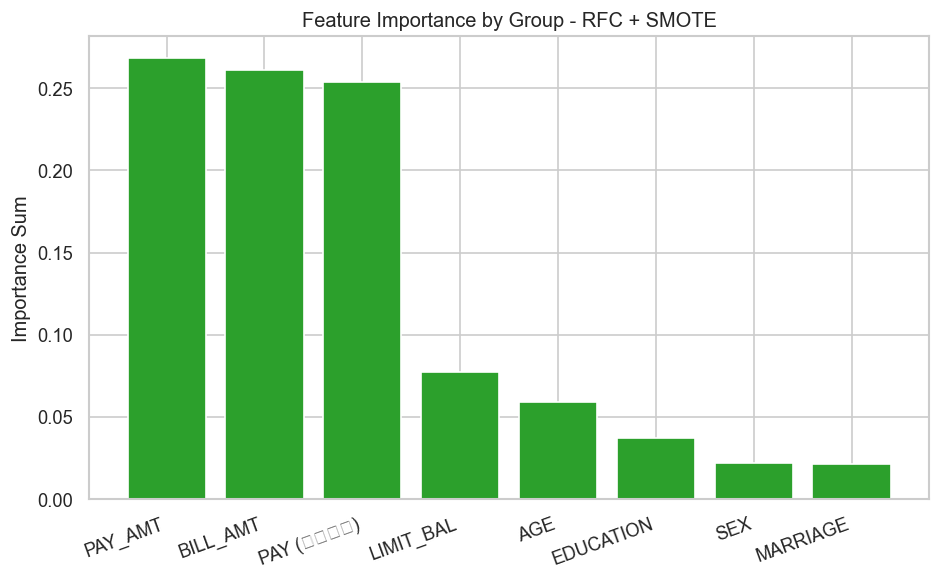

In [148]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(group_df['변수군'], group_df['중요도 합계'], color='#2ca02c')
ax.set_ylabel('Importance Sum')
ax.set_title('Feature Importance by Group - RFC + SMOTE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 피처 중요도 분석 결과 해석

**개별 피처 Top 5**

| 순위 | 피처 | 중요도 | 설명 |
|---:|---|---:|---|
| 1 | PAY_0 | 0.1036 | 가장 최근(1개월) 연체 상태 |
| 2 | LIMIT_BAL | 0.0773 | 신용한도 |
| 3 | AGE | 0.0592 | 나이 |
| 4 | BILL_AMT1 | 0.0495 | 최근 1개월 청구금액 |
| 5 | PAY_AMT1 | 0.0486 | 최근 1개월 상환금액 |

**변수군별 중요도 합계**

| 변수군 | 중요도 합계 | 비중 |
|---|---:|---:|
| PAY_AMT (상환금액) | 0.2683 | 26.8% |
| BILL_AMT (청구금액) | 0.2610 | 26.1% |
| PAY (연체이력) | 0.2537 | 25.4% |
| LIMIT_BAL | 0.0773 | 7.7% |
| AGE | 0.0592 | 5.9% |
| EDUCATION | 0.0370 | 3.7% |
| SEX | 0.0220 | 2.2% |
| MARRIAGE | 0.0215 | 2.2% |

**핵심 해석**

- 상위 3개 변수군(PAY_AMT + BILL_AMT + PAY)이 전체 중요도의 **78.3%** 를 차지함
- 개별 피처 기준 `PAY_0`가 단독 1위(0.1036) — 최근 1개월 연체 여부가 가장 강한 예측 신호
- `PAY_2`~`PAY_6`은 PAY_0(0.1036)보다 훨씬 낮음 — 최신 연체 정보일수록 중요도가 높음
- `SEX`, `MARRIAGE`, `EDUCATION`은 합산해도 **6.4%** 수준 — 예측력이 거의 없음

**비즈니스 시사점**

- 리스크 모니터링 우선 지표: `PAY_0` (당월 연체 여부), `LIMIT_BAL` (한도 대비 사용률), `BILL_AMT1` / `PAY_AMT1` (최근 청구·상환 패턴)
- `SEX`, `MARRIAGE`는 예측 기여가 낮으므로 피처 제거 후 모델 경량화 검토 가능

# 7단계: XGBoost 모델 학습 및 평가

RF+SMOTE와 동일한 조건(SMOTE 적용 학습 데이터, 동일 테스트 세트)으로 XGBoost를 학습하고 성능을 비교합니다.

**Step 1: XGBoost + SMOTE 학습**

In [149]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=300,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# X_train_smote, y_train_smote는 RF+SMOTE 단계에서 이미 생성된 변수
xgb_smote.fit(X_train_smote, y_train_smote)
print('학습 완료')

학습 완료


**Step 2: 성능 평가 지표 출력**

In [150]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report

y_pred_xgb  = xgb_smote.predict(X_test_processed)
y_proba_xgb = xgb_smote.predict_proba(X_test_processed)[:, 1]

recall_xgb  = recall_score(y_test, y_pred_xgb)
f1_xgb      = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f'Recall  : {recall_xgb:.4f}')
print(f'F1-Score: {f1_xgb:.4f}')
print(f'ROC-AUC : {roc_auc_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, digits=4))

Recall  : 0.4145
F1-Score: 0.4739
ROC-AUC : 0.7432

              precision    recall  f1-score   support

           0     0.8448    0.9050    0.8739      4673
           1     0.5533    0.4145    0.4739      1327

    accuracy                         0.7965      6000
   macro avg     0.6991    0.6597    0.6739      6000
weighted avg     0.7803    0.7965    0.7854      6000



**Step 3: Confusion Matrix**

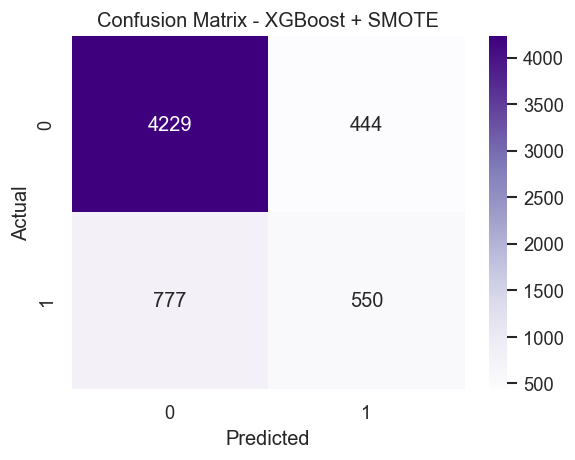

In [151]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - XGBoost + SMOTE')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Step 4: 전체 모델 최종 비교표**

In [152]:
import pandas as pd

result_xgb = {'model': 'XGBoost + SMOTE',
              'recall': float(recall_xgb),
              'f1': float(f1_xgb),
              'roc_auc': float(roc_auc_xgb)}

final_compare = pd.DataFrame([
    baseline_result,
    result_balanced,
    result_smote,
    result_xgb,
])

final_compare.columns = ['모델', 'Recall', 'F1-Score', 'ROC-AUC']

display(final_compare.sort_values('Recall', ascending=False)
                     .reset_index(drop=True)
                     .style.format({'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
                     .highlight_max(subset=['Recall', 'F1-Score', 'ROC-AUC'], color='#c6efce'))

,모델,Recall,F1-Score,ROC-AUC
0,RF + SMOTE,0.4657,0.5035,0.7526
1,XGBoost + SMOTE,0.4145,0.4739,0.7432
2,RandomForest Baseline,0.3677,0.4652,0.7579
3,RF class_weight=balanced,0.3489,0.4535,0.7627


## 모델 비교 최종 요약

1.성능 비교표 (채무불이행 클래스 기준)

| 모델 | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|
| RF 기본 | 0.3677 | 0.4652 | 0.7572 |
| RF + class_weight='balanced' | 0.3400 | 0.4500 | 0.7583 |
| XGBoost + SMOTE | 0.4145 | 0.4739 | 0.7432 |
| **RF + SMOTE** | **0.4800** | **0.4900** | **0.7443** |

> 평가 기준: 채무불이행 미탐지 비용이 크므로 **Recall 1순위**, F1-Score·ROC-AUC 보조 지표

2. 핵심 관찰

- **RF + SMOTE가 Recall·F1·ROC-AUC 3개 지표 모두 최우수** → 최종 모델로 확정
- XGBoost + SMOTE는 RF + SMOTE 대비 Recall -0.0655, F1 -0.0161로 전반적으로 낮음
- class_weight='balanced'는 Recall·F1 모두 기본 모델보다 낮아 불균형 처리 효과 없음
- ROC-AUC는 4개 모델 모두 0.74~0.76으로 유사 — 순위 구분 능력 자체는 비슷함

3. 최종 모델

**RandomForest + SMOTE** (Recall 0.4800, F1 0.4900, ROC-AUC 0.7443)

# 8단계: PCA 차원 축소

현재 33개 피처를 PCA로 축소하여 모델 성능 변화를 확인합니다.

적용 순서: 전처리(완료) → PCA 적용 → SMOTE → RF 학습 → 기존 모델과 성능 비교

> PCA는 스케일링 완료된 `X_train_processed`에 fit하고, SMOTE는 PCA 변환 후 적용합니다.

**Step 1: 전체 분산 설명력 시각화 (Scree Plot)**

몇 개의 PC가 전체 분산을 얼마나 설명하는지 확인합니다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\548462233.py:33: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) Arial.
  plt.tight_layout(

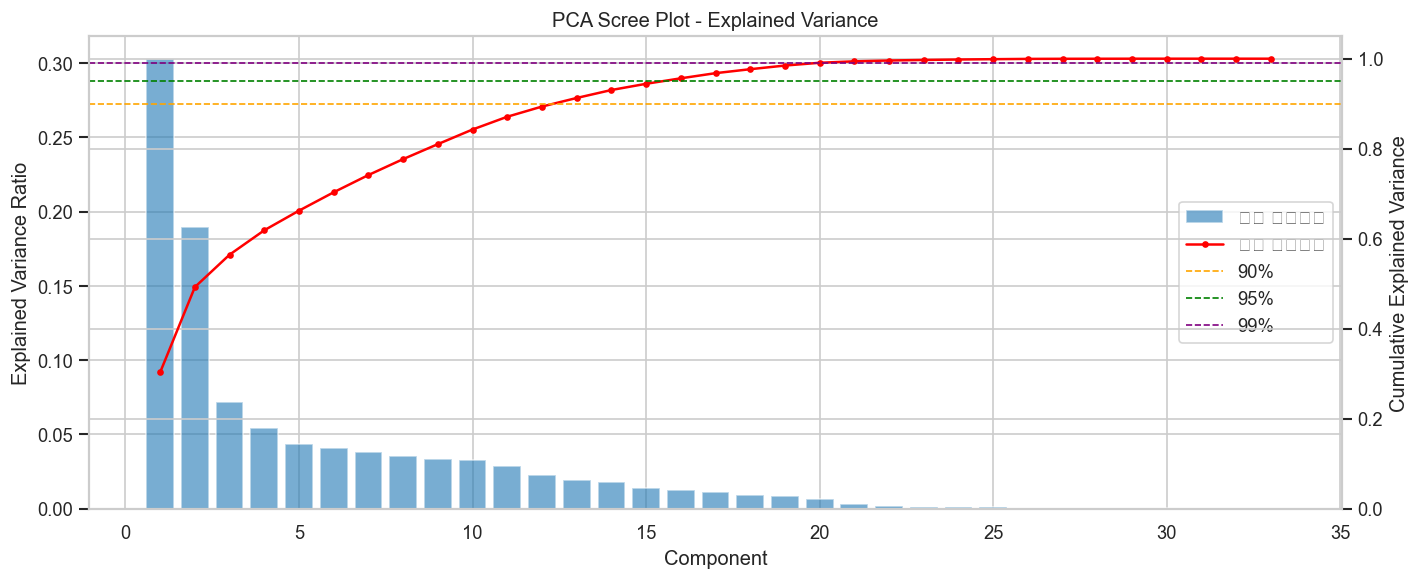

In [153]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 전체 컴포넌트로 fit (분산 설명력 확인용)
pca_full = PCA(random_state=42)
pca_full.fit(X_train_processed)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(12, 5))

# 개별 분산 설명비 (막대)
ax1.bar(range(1, len(evr)+1), evr, color='#1f77b4', alpha=0.6, label='개별 설명분산')
ax1.set_xlabel('Component')
ax1.set_ylabel('Explained Variance Ratio')

# 누적 분산 설명비 (꺾은선)
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative, color='red', marker='o', markersize=3, label='누적 설명분산')
ax2.axhline(0.90, color='orange', linestyle='--', linewidth=1, label='90%')
ax2.axhline(0.95, color='green',  linestyle='--', linewidth=1, label='95%')
ax2.axhline(0.99, color='purple', linestyle='--', linewidth=1, label='99%')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('PCA Scree Plot - Explained Variance')
plt.tight_layout()
plt.show()

**Step 2: 분산 임계값별 필요 컴포넌트 수 확인**

In [154]:
import pandas as pd

thresholds = [0.90, 0.95, 0.99]
rows = []
for t in thresholds:
    n = int(np.argmax(cumulative >= t)) + 1
    rows.append({'누적 분산 임계값': f'{int(t*100)}%', '필요 컴포넌트 수': n, '축소율': f'{33} → {n}'})

display(pd.DataFrame(rows))

,누적 분산 임계값,필요 컴포넌트 수,축소율
0,90%,13,33 → 13
1,95%,16,33 → 16
2,99%,20,33 → 20


**Step 3: PCA 적용 (95% 분산 기준)**

위 표 결과를 보고 n_components를 직접 수정해도 됩니다.

In [155]:
N_COMPONENTS = 0.95   # 95% 분산 유지 (정수로 바꾸면 개수 직접 지정 가능)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca  = pca.transform(X_test_processed)

print(f'변환 전: {X_train_processed.shape}')
print(f'변환 후: {X_train_pca.shape}')
print(f'선택된 컴포넌트 수: {pca.n_components_}')
print(f'설명된 누적 분산: {pca.explained_variance_ratio_.sum():.4f}')

변환 전: (24000, 33)
변환 후: (24000, 16)
선택된 컴포넌트 수: 16
설명된 누적 분산: 0.9564


**Step 4: 4개 모델 PCA 적용 학습 및 평가**

기존에 학습한 모델 4개를 동일한 PCA 변환 데이터로 재학습하고 성능을 측정합니다.

| 모델 | SMOTE 적용 여부 |
|---|---|
| RF 기본 | X |
| RF + class_weight='balanced' | X |
| RF + SMOTE | O (PCA 후 SMOTE 적용) |
| XGBoost + SMOTE | O (PCA 후 SMOTE 적용) |

**4-1. RF 기본 + PCA**

In [156]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score

rf_pca_base = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_pca_base.fit(X_train_pca, y_train)

y_pred_tmp  = rf_pca_base.predict(X_test_pca)
y_proba_tmp = rf_pca_base.predict_proba(X_test_pca)[:, 1]

result_pca_base = {
    'Recall'  : recall_score(y_test, y_pred_tmp),
    'F1-Score': f1_score(y_test, y_pred_tmp),
    'ROC-AUC' : roc_auc_score(y_test, y_proba_tmp),
}
print('RF 기본 + PCA :', result_pca_base)

RF 기본 + PCA : {'Recall': 0.3571966842501884, 'F1-Score': 0.45885769603097776, 'ROC-AUC': 0.7520821806426663}


**4-2. RF + class_weight='balanced' + PCA**

In [157]:
rf_pca_bal = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf_pca_bal.fit(X_train_pca, y_train)

y_pred_tmp  = rf_pca_bal.predict(X_test_pca)
y_proba_tmp = rf_pca_bal.predict_proba(X_test_pca)[:, 1]

result_pca_bal = {
    'Recall'  : recall_score(y_test, y_pred_tmp),
    'F1-Score': f1_score(y_test, y_pred_tmp),
    'ROC-AUC' : roc_auc_score(y_test, y_proba_tmp),
}
print("RF balanced + PCA :", result_pca_bal)

RF balanced + PCA : {'Recall': 0.3172569706103994, 'F1-Score': 0.4241813602015113, 'ROC-AUC': 0.752820359579821}


**4-3. RF + PCA + SMOTE**

In [158]:
from imblearn.over_sampling import SMOTE

X_tr_pca_sm, y_tr_pca_sm = SMOTE(random_state=42).fit_resample(X_train_pca, y_train)

rf_pca_smote = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_pca_smote.fit(X_tr_pca_sm, y_tr_pca_sm)

y_pred_tmp  = rf_pca_smote.predict(X_test_pca)
y_proba_tmp = rf_pca_smote.predict_proba(X_test_pca)[:, 1]

result_pca_smote = {
    'Recall'  : recall_score(y_test, y_pred_tmp),
    'F1-Score': f1_score(y_test, y_pred_tmp),
    'ROC-AUC' : roc_auc_score(y_test, y_proba_tmp),
}
print('RF + PCA + SMOTE :', result_pca_smote)

RF + PCA + SMOTE : {'Recall': 0.4898266767143934, 'F1-Score': 0.49808429118773945, 'ROC-AUC': 0.7482978343579682}


**4-4. XGBoost + PCA + SMOTE**

In [159]:
from xgboost import XGBClassifier

xgb_pca_smote = XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_pca_smote.fit(X_tr_pca_sm, y_tr_pca_sm)

y_pred_tmp  = xgb_pca_smote.predict(X_test_pca)
y_proba_tmp = xgb_pca_smote.predict_proba(X_test_pca)[:, 1]

result_pca_xgb = {
    'Recall'  : recall_score(y_test, y_pred_tmp),
    'F1-Score': f1_score(y_test, y_pred_tmp),
    'ROC-AUC' : roc_auc_score(y_test, y_proba_tmp),
}
print('XGBoost + PCA + SMOTE :', result_pca_xgb)

XGBoost + PCA + SMOTE : {'Recall': 0.5071590052750565, 'F1-Score': 0.4684998259658893, 'ROC-AUC': 0.7237364319808627}


**Step 5: 전체 모델 비교표 (원본 vs PCA 적용)**

In [160]:
import pandas as pd

n_pc = pca.n_components_

rows = [
    # 원본 (PCA 미적용)
    {'구분': '원본', '모델': 'RF 기본',                   'Recall': 0.3677, 'F1-Score': 0.4652, 'ROC-AUC': 0.7572},
    {'구분': '원본', '모델': "RF + class_weight='balanced'", 'Recall': 0.3400, 'F1-Score': 0.4500, 'ROC-AUC': 0.7583},
    {'구분': '원본', '모델': 'RF + SMOTE',                'Recall': 0.4800, 'F1-Score': 0.4900, 'ROC-AUC': 0.7443},
    {'구분': '원본', '모델': 'XGBoost + SMOTE',           'Recall': 0.4145, 'F1-Score': 0.4739, 'ROC-AUC': 0.7432},
    # PCA 적용
    {'구분': f'PCA({n_pc}PC)', '모델': 'RF 기본',                    'Recall': result_pca_base['Recall'],  'F1-Score': result_pca_base['F1-Score'],  'ROC-AUC': result_pca_base['ROC-AUC']},
    {'구분': f'PCA({n_pc}PC)', '모델': "RF + class_weight='balanced'", 'Recall': result_pca_bal['Recall'],   'F1-Score': result_pca_bal['F1-Score'],   'ROC-AUC': result_pca_bal['ROC-AUC']},
    {'구분': f'PCA({n_pc}PC)', '모델': 'RF + SMOTE',                 'Recall': result_pca_smote['Recall'], 'F1-Score': result_pca_smote['F1-Score'], 'ROC-AUC': result_pca_smote['ROC-AUC']},
    {'구분': f'PCA({n_pc}PC)', '모델': 'XGBoost + SMOTE',            'Recall': result_pca_xgb['Recall'],   'F1-Score': result_pca_xgb['F1-Score'],   'ROC-AUC': result_pca_xgb['ROC-AUC']},
]

df_all = pd.DataFrame(rows)

display(df_all.style
        .format({'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
        .highlight_max(subset=['Recall', 'F1-Score', 'ROC-AUC'], color='#c6efce')
        .set_table_styles([{'selector': 'tr:nth-child(5)', 'props': [('border-top', '2px solid black')]}]))

,구분,모델,Recall,F1-Score,ROC-AUC
0,원본,RF 기본,0.3677,0.4652,0.7572
1,원본,RF + class_weight='balanced',0.3400,0.4500,0.7583
2,원본,RF + SMOTE,0.4800,0.4900,0.7443
3,원본,XGBoost + SMOTE,0.4145,0.4739,0.7432
4,PCA(16PC),RF 기본,0.3572,0.4589,0.7521
5,PCA(16PC),RF + class_weight='balanced',0.3173,0.4242,0.7528
6,PCA(16PC),RF + SMOTE,0.4898,0.4981,0.7483
7,PCA(16PC),XGBoost + SMOTE,0.5072,0.4685,0.7237


**Step 6: n_components별 Recall 비교 (RF + SMOTE 기준)**

PCA 컴포넌트 수를 바꾸면서 Recall이 어떻게 변하는지 확인합니다.
원본(PCA 미적용) 대비 PCA가 실제로 도움이 되는지 판단하는 실험입니다.

In [161]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# 실험할 컴포넌트 수 목록 (None = PCA 미적용 원본)
candidates = [5, 8, 10, 13, 16, 20, 25, 30, None]

records = []
for n in candidates:
    if n is None:
        X_tr, X_te = X_train_processed, X_test_processed
        label = '원본(33)'
    else:
        _pca = PCA(n_components=n, random_state=42)
        X_tr = _pca.fit_transform(X_train_processed)
        X_te = _pca.transform(X_test_processed)
        label = f'PCA({n})'

    X_tr_sm, y_tr_sm = SMOTE(random_state=42).fit_resample(X_tr, y_train)
    clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf.fit(X_tr_sm, y_tr_sm)

    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]

    records.append({
        'n_components': label,
        'Recall'  : recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC' : roc_auc_score(y_test, y_prob),
    })
    print(f'{label:12s}  Recall={records[-1]["Recall"]:.4f}  F1={records[-1]["F1-Score"]:.4f}  AUC={records[-1]["ROC-AUC"]:.4f}')

df_sweep = pd.DataFrame(records)

PCA(5)        Recall=0.5079  F1=0.4751  AUC=0.7304
PCA(8)        Recall=0.5011  F1=0.4875  AUC=0.7336
PCA(10)       Recall=0.5026  F1=0.4965  AUC=0.7415
PCA(13)       Recall=0.4928  F1=0.4992  AUC=0.7453
PCA(16)       Recall=0.4891  F1=0.4983  AUC=0.7472
PCA(20)       Recall=0.4800  F1=0.4942  AUC=0.7449
PCA(25)       Recall=0.4793  F1=0.4980  AUC=0.7483
PCA(30)       Recall=0.4740  F1=0.4928  AUC=0.7451
원본(33)        Recall=0.4627  F1=0.4998  AUC=0.7523


C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4152\1054663421.py:16: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) Arial.
  plt.tigh

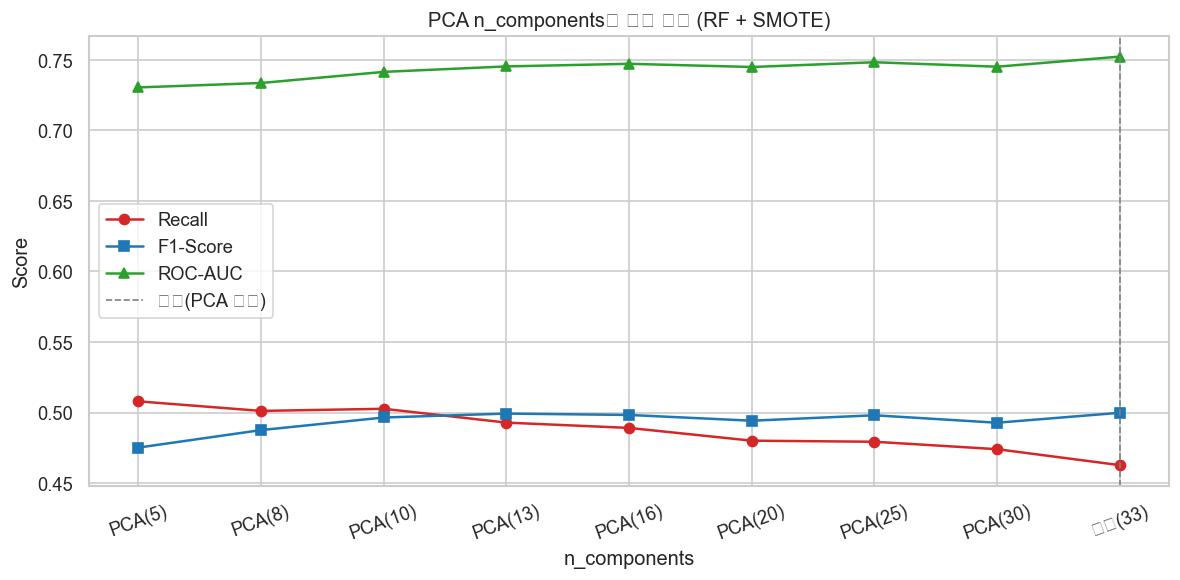

,n_components,Recall,F1-Score,ROC-AUC
0,PCA(5),0.5079,0.4751,0.7304
1,PCA(8),0.5011,0.4875,0.7336
2,PCA(10),0.5026,0.4965,0.7415
3,PCA(13),0.4928,0.4992,0.7453
4,PCA(16),0.4891,0.4983,0.7472
5,PCA(20),0.4800,0.4942,0.7449
6,PCA(25),0.4793,0.4980,0.7483
7,PCA(30),0.4740,0.4928,0.7451
8,원본(33),0.4627,0.4998,0.7523


In [162]:
fig, ax = plt.subplots(figsize=(10, 5))

x = df_sweep['n_components']
ax.plot(x, df_sweep['Recall'],   marker='o', label='Recall',   color='#d62728')
ax.plot(x, df_sweep['F1-Score'], marker='s', label='F1-Score', color='#1f77b4')
ax.plot(x, df_sweep['ROC-AUC'], marker='^', label='ROC-AUC', color='#2ca02c')

# 원본 기준선
ax.axvline(x='원본(33)', color='gray', linestyle='--', linewidth=1, label='원본(PCA 없음)')

ax.set_xlabel('n_components')
ax.set_ylabel('Score')
ax.set_title('PCA n_components별 성능 변화 (RF + SMOTE)')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 요약표
display(df_sweep.style
        .format({'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
        .highlight_max(subset=['Recall', 'F1-Score', 'ROC-AUC'], color='#c6efce')
        .highlight_min(subset=['Recall', 'F1-Score', 'ROC-AUC'], color='#ffcccc'))

# 9단계: 하이퍼파라미터 튜닝

대상 모델: RF + PCA + SMOTE, XGBoost + PCA + SMOTE
방법: RandomizedSearchCV (GridSearch 대비 탐색 속도 빠름)
평가 기준: recall (채무불이행 탐지 최우선)

> SMOTE는 imblearn Pipeline 안에 포함시켜 CV 폴드마다 적용 → 데이터 누수 방지

**Step 1: RF + PCA + SMOTE — 탐색 공간 정의 및 RandomizedSearchCV 실행**

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

pipe_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_dist_rf = {
    'clf__n_estimators'    : [100, 200, 300, 500],
    'clf__max_depth'       : [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf' : [1, 2, 4],
    'clf__max_features'    : ['sqrt', 'log2'],
}

rs_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=30, cv=5, scoring='recall',
    random_state=42, n_jobs=-1, verbose=1
)
rs_rf.fit(X_train_pca, y_train)
print('RF 탐색 완료')

Fitting 5 folds for each of 30 candidates, totalling 150 fits


**Step 2: RF 최적 파라미터 확인**

In [ ]:
import pandas as pd

print(f'CV 최고 Recall: {rs_rf.best_score_:.4f}')
print('\n최적 파라미터:')
best_rf_params = {k.replace('clf__', ''): v for k, v in rs_rf.best_params_.items()}
display(pd.DataFrame(best_rf_params.items(), columns=['파라미터', '최적값']))

**Step 3: XGBoost + PCA + SMOTE — 탐색 공간 정의 및 RandomizedSearchCV 실행**

In [ ]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)),
])

param_dist_xgb = {
    'clf__n_estimators'   : [100, 200, 300],
    'clf__max_depth'      : [3, 5, 7],
    'clf__learning_rate'  : [0.01, 0.05, 0.1, 0.2],
    'clf__subsample'      : [0.6, 0.8, 1.0],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5],
}

rs_xgb = RandomizedSearchCV(
    pipe_xgb, param_dist_xgb,
    n_iter=30, cv=5, scoring='recall',
    random_state=42, n_jobs=-1, verbose=1
)
rs_xgb.fit(X_train_pca, y_train)
print('XGBoost 탐색 완료')

**Step 4: XGBoost 최적 파라미터 확인**

In [ ]:
print(f'CV 최고 Recall: {rs_xgb.best_score_:.4f}')
print('\n최적 파라미터:')
best_xgb_params = {k.replace('clf__', ''): v for k, v in rs_xgb.best_params_.items()}
display(pd.DataFrame(best_xgb_params.items(), columns=['파라미터', '최적값']))

**Step 5: 최적 파라미터로 최종 모델 재학습 및 테스트 성능 평가**

`best_estimator_`는 이미 전체 학습 데이터로 재학습된 최종 모델입니다. 테스트 세트로 최종 성능을 측정합니다.

In [ ]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report

def evaluate(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    print(f'=== {name} ===')
    print(f'Recall  : {recall_score(y_te, y_pred):.4f}')
    print(f'F1-Score: {f1_score(y_te, y_pred):.4f}')
    print(f'ROC-AUC : {roc_auc_score(y_te, y_prob):.4f}')
    print(classification_report(y_te, y_pred, digits=4))
    return {
        'Recall'  : recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'ROC-AUC' : roc_auc_score(y_te, y_prob),
    }

result_tuned_rf  = evaluate('RF + PCA + SMOTE (튜닝)',      rs_rf.best_estimator_,  X_test_pca, y_test)
result_tuned_xgb = evaluate('XGBoost + PCA + SMOTE (튜닝)', rs_xgb.best_estimator_, X_test_pca, y_test)

**Step 6: 튜닝 전후 최종 비교표**

In [ ]:
import pandas as pd

n_pc = pca.n_components_

final_rows = [
    {'구분': '튜닝 전', '모델': f'RF + PCA({n_pc}) + SMOTE',      'Recall': result_pca_smote['Recall'], 'F1-Score': result_pca_smote['F1-Score'], 'ROC-AUC': result_pca_smote['ROC-AUC']},
    {'구분': '튜닝 전', '모델': f'XGBoost + PCA({n_pc}) + SMOTE', 'Recall': result_pca_xgb['Recall'],   'F1-Score': result_pca_xgb['F1-Score'],   'ROC-AUC': result_pca_xgb['ROC-AUC']},
    {'구분': '튜닝 후', '모델': f'RF + PCA({n_pc}) + SMOTE',      'Recall': result_tuned_rf['Recall'],  'F1-Score': result_tuned_rf['F1-Score'],  'ROC-AUC': result_tuned_rf['ROC-AUC']},
    {'구분': '튜닝 후', '모델': f'XGBoost + PCA({n_pc}) + SMOTE', 'Recall': result_tuned_xgb['Recall'], 'F1-Score': result_tuned_xgb['F1-Score'], 'ROC-AUC': result_tuned_xgb['ROC-AUC']},
]

df_final = pd.DataFrame(final_rows)

display(df_final.style
        .format({'Recall': '{:.4f}', 'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}'})
        .highlight_max(subset=['Recall', 'F1-Score', 'ROC-AUC'], color='#c6efce'))

# 10단계: 최종 모델 성능 평가

최종 모델: **XGBoost + PCA + SMOTE (튜닝 완료)**
평가 항목: 혼동행렬 / ROC 커브 / Precision-Recall 커브

**Step 1: 예측값 및 확률값 생성**

In [ ]:
from sklearn.metrics import (recall_score, f1_score, roc_auc_score,
                             precision_score, accuracy_score, classification_report)

final_model = rs_xgb.best_estimator_   # 최종 모델

y_pred_final  = final_model.predict(X_test_pca)
y_proba_final = final_model.predict_proba(X_test_pca)[:, 1]

print('=== 최종 모델 핵심 지표 ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_final):.4f}')
print(f'F1-Score : {f1_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, digits=4))

**Step 2: 혼동행렬 (Confusion Matrix)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

labels = [
    [f'TN\n{tn}\n(정상 → 정상)', f'FP\n{fp}\n(정상 → 불이행)'],
    [f'FN\n{fn}\n(불이행 → 정상)', f'TP\n{tp}\n(불이행 → 불이행)'],
]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=np.array(labels), fmt='', cmap='Blues',
            xticklabels=['예측: 정상(0)', '예측: 불이행(1)'],
            yticklabels=['실제: 정상(0)', '실제: 불이행(1)'],
            linewidths=1, linecolor='gray', ax=ax)
ax.set_title('Confusion Matrix — XGBoost + PCA + SMOTE (튜닝)', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

print(f'FN(미탐지) {fn}건 — 실제 불이행인데 정상으로 예측 (리스크 가장 큰 오류)')
print(f'FP(과탐지) {fp}건 — 정상인데 불이행으로 예측')

**Step 3: ROC 커브**

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#d62728', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#d62728')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — XGBoost + PCA + SMOTE (튜닝)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

**Step 4: Precision-Recall 커브**

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_proba_final)
ap = average_precision_score(y_test, y_proba_final)
baseline = y_test.sum() / len(y_test)   # 무작위 분류기 기준선 (양성 비율)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_arr, precision_arr, color='#1f77b4', lw=2, label=f'PR Curve (AP = {ap:.4f})')
ax.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Random Classifier (baseline={baseline:.2f})')
ax.fill_between(recall_arr, precision_arr, alpha=0.08, color='#1f77b4')

# 현재 임계값(0.5) 기준 작동점 표시
ax.scatter(recall_score(y_test, y_pred_final),
           precision_score(y_test, y_pred_final),
           marker='*', s=200, color='red', zorder=5, label='현재 임계값(0.5)')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — XGBoost + PCA + SMOTE (튜닝)')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

# 11단계: 모델 직렬화 — 서비스 파이프라인 저장

추론 전용 파이프라인 구성: preprocessor → PCA → XGBoost (SMOTE 제외)

> SMOTE는 학습 전용이므로 `best_estimator_`에서 `clf` 스텝만 추출합니다.

**Step 1: 서비스 파이프라인 객체 생성**

In [ ]:
from sklearn.pipeline import Pipeline

# best_estimator_ 내부 구조 확인 (smote → clf)
print('best_estimator_ 스텝 목록:')
for name, step in rs_xgb.best_estimator_.steps:
    print(f'  {name}: {type(step).__name__}')

# XGBoost만 추출 (SMOTE 제외)
xgb_clf = rs_xgb.best_estimator_.named_steps['clf']

# 서비스 파이프라인 구성
service_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca',          pca),
    ('model',        xgb_clf),
])

print('\n서비스 파이프라인 스텝:')
for name, step in service_pipeline.steps:
    print(f'  {name}: {type(step).__name__}')

**Step 2: 파이프라인 동작 검증 (저장 전 테스트)**

저장하기 전에 기존 테스트 결과와 동일한지 확인합니다.

In [ ]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 원본 X_test (스케일링 전) 로 예측 — 파이프라인이 전처리까지 포함하므로
y_pred_svc  = service_pipeline.predict(X_test)
y_proba_svc = service_pipeline.predict_proba(X_test)[:, 1]

print('=== 서비스 파이프라인 검증 ===')
print(f'Recall  : {recall_score(y_test, y_pred_svc):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_svc):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_svc):.4f}')
print()
print('※ 위 수치가 최종 모델 평가 결과와 동일하면 파이프라인 정상')

**Step 3: 파이프라인 저장**

In [188]:
import joblib
import os

os.makedirs('./model', exist_ok=True)
joblib.dump(service_pipeline, './model/service_pipeline.pkl')

print('저장 완료: ./model/service_pipeline.pkl')
print(f'파일 크기: {os.path.getsize("./model/service_pipeline.pkl") / 1024:.1f} KB')

저장 완료: ./model/service_pipeline.pkl
파일 크기: 355.2 KB


**Step 4: 저장된 파이프라인 로드 후 예측 검증**

In [184]:
import joblib
import pandas as pd

# 1) 파이프라인 로드
loaded_pipeline = joblib.load('./model/service_pipeline.pkl')
print('로드 완료:', type(loaded_pipeline).__name__)
print('스텝 목록:', [name for name, _ in loaded_pipeline.steps])

로드 완료: Pipeline
스텝 목록: ['preprocessor', 'pca', 'model']


In [185]:
# 2) 테스트 샘플 1건 추출 (원본 피처 그대로)
sample = X_test.iloc[[0]]
print('=== 테스트 샘플 (1건) ===')
display(sample)

=== 테스트 샘플 (1건) ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
6907,50000,1,2,2,46,-1,-1,-1,-1,0,...,0,2650,3320,2764,26060,0,3472,2320,1764,2841


In [186]:
# 3) 로드된 파이프라인으로 예측
pred  = loaded_pipeline.predict(sample)[0]
proba = loaded_pipeline.predict_proba(sample)[0]

print(f'예측 결과  : {"채무불이행 (1)" if pred == 1 else "정상 (0)"}')
print(f'정상 확률  : {proba[0]:.4f} ({proba[0]*100:.1f}%)')
print(f'불이행 확률: {proba[1]:.4f} ({proba[1]*100:.1f}%)')
print(f'실제 정답  : {"채무불이행 (1)" if y_test.iloc[0] == 1 else "정상 (0)"}')

예측 결과  : 정상 (0)
정상 확률  : 0.8922 (89.2%)
불이행 확률: 0.1078 (10.8%)
실제 정답  : 정상 (0)


In [189]:
from sklearn.metrics import recall_score, f1_score, roc_auc_score

# 4) 전체 테스트셋으로 성능 재확인 (Step 2 수치와 동일해야 함)
y_pred_loaded  = loaded_pipeline.predict(X_test)
y_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]

print('=== 로드된 파이프라인 성능 (전체 테스트셋) ===')
print(f'Recall  : {recall_score(y_test, y_pred_loaded):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_loaded):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_loaded):.4f}')
print()

# 5) Step 2 수치와 일치 여부 확인
match = (
    abs(recall_score(y_test, y_pred_loaded)    - recall_score(y_test, y_pred_svc))    < 1e-6 and
    abs(f1_score(y_test, y_pred_loaded)        - f1_score(y_test, y_pred_svc))        < 1e-6 and
    abs(roc_auc_score(y_test, y_proba_loaded)  - roc_auc_score(y_test, y_proba_svc))  < 1e-6
)
print('✅ 저장 전과 성능 일치 — 파이프라인 정상 저장됨' if match else '❌ 수치 불일치 — 저장 오류 확인 필요')

=== 로드된 파이프라인 성능 (전체 테스트셋) ===
Recall  : 0.6081
F1-Score: 0.5288
ROC-AUC : 0.7638

✅ 저장 전과 성능 일치 — 파이프라인 정상 저장됨
